# Beam + TimesFM Multi-Dataset Benchmark — Two-Stage LoRA + RLAIF

**Pipeline:**
1. TimesFM forecasting on streaming windows (Apache Beam).
2. IQR-band anomaly detection from TimesFM quantiles.
3. LLM judge (Gemini or Claude) filters anomalies (KEEP / REMOVE).
4. **Stage 1 (SFT):** LoRA fine-tunes TimesFM on KEEP-filtered windows.
5. **Stage 2 (RL):** Continues training the same LoRA adapter with REINFORCE,
   reward = α·calibration − β·sharpness + γ·LLM_quality_score, with KL penalty
   against the SFT policy.
6. Held-out evaluation (last 15% of each series).

## Datasets

| Dataset | Points | Domain |
|---|---|---|
| `nyc_taxi` | 10,320 | Urban transport |
| `nab_machine` | ~22,695 | IoT sensor / industrial machine |
| `smd_1_1` | ~28,479 | IT infrastructure / server |

## Conditions per dataset (5)

| Condition | Stage 1 | Stage 2 RL |
|---|---|---|
| Static (no FT) | — | — |
| Naive LoRA | no judge | — |
| SFT + Gemini | Gemini judge | — |
| SFT + Claude | Claude judge | — |
| **SFT + RL** | Gemini judge | **REINFORCE + LLM reward** |

Total: 15 trained or evaluated models.

## How to run

Run cells top-to-bottom. The orchestration cell loops over the 3 datasets
and trains all 5 conditions for each. Wall-clock: roughly 1–3 hours,
dominated by the RL stage and LLM API calls.


## Setup

In [1]:
import sys, apache_beam as beam
print("Python:", sys.version)
print("Beam:", beam.__version__)

Python: 3.11.14 | packaged by Anaconda, Inc. | (main, Oct 21 2025, 18:30:03) [MSC v.1929 64 bit (AMD64)]
Beam: 2.67.0


In [2]:
# FIX: Beam 2.67 bug — "unhashable type: 'list'" in stateful DoFns
from apache_beam.runners.worker import bundle_processor

_orig_create = bundle_processor.FnApiUserStateContext._create_state

def _safe_get_state(self, *args):
    # FIX: instead of converting args to hashable types (which fails for
    # Beam's internal Protobuf state key objects), use repr() as the cache key.
    # repr() always returns a plain string — guaranteed hashable.
    try:
        # Try the normal path first (fast)
        state_handle = self._all_states.get(args)
        if state_handle is None:
            state_handle = self._all_states[args] = _orig_create(self, *args)
        return state_handle
    except TypeError:
        # args contains something unhashable (Beam 2.67 bug).
        # Fall back: use string representation as key.
        str_key = repr(args)
        state_handle = self._all_states.get(str_key)
        if state_handle is None:
            state_handle = self._all_states[str_key] = _orig_create(self, *args)
        return state_handle

bundle_processor.FnApiUserStateContext.get_state = _safe_get_state
print("Patched Beam 2.67 state hashing bug")

Patched Beam 2.67 state hashing bug


In [3]:
# FIX #2: Beam 2.67 — "unhashable type: 'list'" in _collect_written_timers
from apache_beam.runners.portability.fn_api_runner import fn_runner

def _h(obj):
    """Make ANY unhashable object hashable."""
    try:
        hash(obj)
        return obj
    except TypeError:
        if hasattr(obj, '__iter__'):
            return tuple(_h(x) for x in obj)
        return id(obj)

_src = '''
@staticmethod
def _collect_written_timers(bundle_context_manager):
    timer_watermark_data = {}
    newly_set_timers = {}
    for (transform_id, timer_family_id) in bundle_context_manager.stage.timers:
        written_timers = bundle_context_manager.get_buffer(
            create_buffer_id(timer_family_id, kind='timers'), transform_id)
        assert isinstance(written_timers, ListBuffer)
        timer_coder_impl = bundle_context_manager.get_timer_coder_impl(
            transform_id, timer_family_id)
        if not written_timers.cleared:
            timers_by_key_tag_and_window = {}
            for elements_timers in written_timers:
                for decoded_timer in timer_coder_impl.decode_all(elements_timers):
                    key_tag_win = (
                        _h(decoded_timer.user_key),
                        _h(decoded_timer.dynamic_timer_tag),
                        _h(decoded_timer.windows[0]))
                    if not decoded_timer.clear_bit:
                        timers_by_key_tag_and_window[key_tag_win] = decoded_timer
                    elif (decoded_timer.clear_bit and
                          key_tag_win in timers_by_key_tag_and_window):
                        del timers_by_key_tag_and_window[key_tag_win]

            out = create_OutputStream()
            for decoded_timer in timers_by_key_tag_and_window.values():
                if not decoded_timer.clear_bit:
                    timer_coder_impl.encode_to_stream(decoded_timer, out, True)
                    if (transform_id, timer_family_id) not in timer_watermark_data:
                        timer_watermark_data[(transform_id,
                                              timer_family_id)] = timestamp.MAX_TIMESTAMP
                    timer_watermark_data[(transform_id, timer_family_id)] = min(
                        timer_watermark_data[(transform_id, timer_family_id)],
                        decoded_timer.hold_timestamp)
            if (transform_id, timer_family_id) not in timer_watermark_data:
                continue
            newly_set_timers[(transform_id, timer_family_id)] = (
                ListBuffer(coder_impl=timer_coder_impl),
                timer_watermark_data[(transform_id, timer_family_id)])
            newly_set_timers[(transform_id, timer_family_id)][0].append(out.get())
            written_timers.clear()

    return timer_watermark_data, newly_set_timers
'''

_ns = dict(fn_runner.__dict__)
_ns['_h'] = _h
exec(compile(_src, "<beam_patch>", "exec"), _ns)
fn_runner.FnApiRunner._collect_written_timers = _ns['_collect_written_timers']
print("Patched _collect_written_timers")
print("Verify:", fn_runner.FnApiRunner._collect_written_timers.__code__.co_filename)

Patched _collect_written_timers
Verify: <beam_patch>


Cell 2: Ordered Sliding Window

In [4]:
import logging

import apache_beam as beam
from apache_beam.coders import BooleanCoder
from apache_beam.coders import PickleCoder
from apache_beam.coders import TimestampCoder
from apache_beam.transforms.timeutil import TimeDomain
from apache_beam.transforms.userstate import OrderedListStateSpec
from apache_beam.transforms.userstate import ReadModifyWriteStateSpec
from apache_beam.transforms.userstate import TimerSpec
from apache_beam.transforms.userstate import on_timer
from apache_beam.utils.timestamp import MAX_TIMESTAMP
from apache_beam.utils.timestamp import Timestamp

_LOGGER = logging.getLogger(__name__)
logging.basicConfig(level=logging.INFO)
_LOGGER.setLevel(logging.INFO)


class OrderedSlidingWindowFn(beam.DoFn):

  ORDERED_BUFFER_STATE = OrderedListStateSpec('ordered_buffer', PickleCoder())
  WINDOW_TIMER = TimerSpec('window_timer', TimeDomain.WATERMARK)
  TIMER_STATE = ReadModifyWriteStateSpec('timer_state', BooleanCoder())
  EARLIEST_TS_STATE = ReadModifyWriteStateSpec('earliest_ts', TimestampCoder())

  def __init__(self, window_size, slide_interval):
    self.window_size = window_size
    self.slide_interval = slide_interval

  def start_bundle(self):
    _LOGGER.debug("start bundle")

  def finish_bundle(self):
    _LOGGER.debug("finish bundle")

  def process(
      self,
      element,
      timestamp=beam.DoFn.TimestampParam,
      ordered_buffer=beam.DoFn.StateParam(ORDERED_BUFFER_STATE),
      window_timer=beam.DoFn.TimerParam(WINDOW_TIMER),
      timer_state=beam.DoFn.StateParam(TIMER_STATE),
      earliest_ts_state=beam.DoFn.StateParam(EARLIEST_TS_STATE)):

    _, value = element
    ordered_buffer.add((timestamp, value))

    _LOGGER.debug("receive %s at %s", element, timestamp)
    timer_started = timer_state.read()

    earliest = earliest_ts_state.read()
    if not earliest or earliest > timestamp:
      earliest_ts_state.write(timestamp)

    if not timer_started:
      earliest_ts_state.write(timestamp)

      first_slide_start = int(
          timestamp.micros / 1e6 // self.slide_interval) * self.slide_interval
      first_slide_start_ts = Timestamp.of(first_slide_start)

      first_window_end_ts = first_slide_start_ts + self.window_size
      _LOGGER.debug("set timer to %s", first_window_end_ts)
      window_timer.set(first_window_end_ts)

      timer_state.write(True)

    return []

  @on_timer(WINDOW_TIMER)
  def on_timer(
      self,
      key=beam.DoFn.KeyParam,
      fire_ts=beam.DoFn.TimestampParam,
      ordered_buffer=beam.DoFn.StateParam(ORDERED_BUFFER_STATE),
      window_timer=beam.DoFn.TimerParam(WINDOW_TIMER),
      timer_state=beam.DoFn.StateParam(TIMER_STATE),
      earliest_ts_state=beam.DoFn.StateParam(EARLIEST_TS_STATE)):
    _LOGGER.debug("timer fire at %s", fire_ts)
    window_end_ts = fire_ts
    window_start_ts = window_end_ts - self.window_size

    window_values = list(
        ordered_buffer.read_range(window_start_ts, window_end_ts))

    _LOGGER.debug(
        "window start: %s, window end: %s", window_start_ts, window_end_ts)
    _LOGGER.debug("windowed data in buffer %s", str(window_values))
    if window_values:
      yield (key, (window_start_ts, window_end_ts, window_values))

    next_window_end_ts = fire_ts + self.slide_interval
    next_window_start_ts = window_start_ts + self.slide_interval

    earliest_ts = earliest_ts_state.read()
    ordered_buffer.clear_range(earliest_ts, next_window_start_ts)

    remaining_data = list(
        ordered_buffer.read_range(next_window_start_ts, MAX_TIMESTAMP))

    if not remaining_data:
      timer_state.clear()
      earliest_ts_state.write(next_window_start_ts)
      return

    _LOGGER.debug("set timer to %s", next_window_end_ts)
    window_timer.set(next_window_end_ts)


class FillGapsFn(beam.DoFn):
  def __init__(self, expected_interval: float):
    """
    Args:
      expected_interval: The expected time delta between elements, in seconds.
    """
    self.expected_interval = expected_interval

  def process(self, element):
    key, (window_start_ts, window_end_ts, window_elements) = element

    received_data = {
        round(float(ts.micros / 1e6), 5): val
        for ts, val in window_elements
    }

    start_sec = float(window_start_ts.micros / 1e6)
    end_sec = float(window_end_ts.micros / 1e6)

    filled_values = []
    current_ts_sec = start_sec

    while current_ts_sec < end_sec:
      lookup_ts = round(current_ts_sec, 5)

      if lookup_ts in received_data:
        filled_values.append(float(received_data[lookup_ts]))
      else:
        filled_values.append('NaN')

      current_ts_sec += self.expected_interval

    yield (key, (window_start_ts, window_end_ts, filled_values))


Cell 3: Model Handler

In [5]:
import apache_beam as beam
from apache_beam.ml.inference.base import ModelHandler
import timesfm
import logging
import numpy as np
import os
from google.cloud import storage
from apache_beam.io.gcp.gcsio import GcsIO
from apache_beam.utils.timestamp import Timestamp

class LatestModelCheckpointLoader(beam.PTransform):
    """A PTransform that finds the latest model checkpoint in a GCS path."""
    def __init__(self, gcs_bucket, gcs_prefix):
        self.gcs_bucket = gcs_bucket
        self.gcs_prefix = gcs_prefix

    def expand(self, pcoll):
        return pcoll | "FindLatestModel" >> beam.Map(self._find_latest_model_path)

    def _find_latest_model_path(self, _):
        try:
            storage_client = storage.Client()
            blobs = storage_client.list_blobs(self.gcs_bucket, prefix=self.gcs_prefix)
            # Filter for model files and find the most recent one
            model_blobs = [b for b in blobs if b.name.endswith(".pth")]
            latest_blob = max(model_blobs, key=lambda b: b.time_created, default=None)

            if latest_blob:
                path = f"gs://{self.gcs_bucket}/{latest_blob.name}"
                logging.info(f"Found latest finetuned model at: {path}")
                return path
        except Exception as e:
            logging.error(f"Error finding latest model in GCS: {e}")

        # Return a path to the base model if no finetuned one exists or an error occurs
        base_model = "google/timesfm-1.0-200m-pytorch"
        logging.info(f"No finetuned model found. Using base model: {base_model}")
        return base_model

class DynamicTimesFmModelHandler(ModelHandler[np.ndarray, np.ndarray, timesfm.TimesFm]):
    """
    A model handler that loads a TimesFM model from a dynamic path (GCS or Hugging Face).
    The model path is provided as a side input to RunInference.
    """
    def __init__(self, model_uri: str, hparams):
        self._hparams = hparams
        self._model = None
        self._model_uri = model_uri
        self._context_len = hparams.context_len
        self._horizon_len = hparams.horizon_len

    def load_model(self) -> timesfm.TimesFm:
        logging.info(f"Loading TimesFM model from path: {self._model_uri}...")

        checkpoint_config = {}
        if self._model_uri.startswith("gs://"):
            try:
                gcs = GcsIO()
                file_name = os.path.basename(self._model_uri)
                local_path = f"/tmp/{file_name}"
                with gcs.open(self._model_uri, 'rb') as f_in, open(local_path, 'wb') as f_out:
                    f_out.write(f_in.read())
                checkpoint_config['path'] = local_path
                logging.info(f"Downloaded model from GCS to {local_path}")
            except Exception as e:
                logging.error(f"Failed to download model from GCS: {e}.")
                raise e
        elif os.path.isfile(self._model_uri):
            checkpoint_config['path'] = self._model_uri
            logging.info(f"Loading local checkpoint: {self._model_uri}")
        else:
            checkpoint_config['huggingface_repo_id'] = self._model_uri

        # ── FIX: actually create and return the model ──
        tfm = timesfm.TimesFm(
            hparams=self._hparams,
            checkpoint=timesfm.TimesFmCheckpoint(**checkpoint_config)
        )
        self._model = tfm
        logging.info("Model loaded successfully.")
        return tfm

    def update_model_path(self, model_path: str):
        """
        This method is called by RunInference when a new model metadata is available
        from the side input. It updates the model URI that `load_model` will use.
        """
        if not model_path:
            logging.info("Received an empty model path update. No action taken.")
            return
        logging.info(f"Received model update. New model URI: {model_path}")
        self._model_uri = model_path
        self._model = self.load_model()
        logging.info("Model has been updated in the handler.")

    def run_inference(self, batch, model, inference_args=None):
        if self._model is None:
            if self._model_uri.endswith('.pth') and os.path.isfile(self._model_uri):
                import torch
                base = timesfm.TimesFm(
                    hparams=self._hparams,
                    checkpoint=timesfm.TimesFmCheckpoint(
                        huggingface_repo_id="google/timesfm-1.0-200m-pytorch"
                    )
                )
                # FIX: inject LoRA adapters BEFORE loading weights
                inject_lora(base._model, rank=4, alpha=1.0)
                state = torch.load(self._model_uri, map_location='cpu')
                try:
                    
                    missing, unexpected = base._model.load_state_dict(state, strict=False)
                    logging.info(
                        f"Loaded LoRA weights from {self._model_uri} | "
                        f"missing={len(missing)} unexpected={len(unexpected)}"
                    )
                    self._model = base
                except RuntimeError as e:
                    logging.warning(
                        f"Could not load LoRA weights ({e}). "
                        f"Using base model instead."
                    )
                    self._model = base
            else:
                self.load_model()

        # FIX: prefer the model Beam passed in (it's the canonical
        # output of load_model()).  Fall back to self._model only
        # for the .pth-LoRA branch above, which writes to self._model
        # directly.
        tfm = model if model is not None else self._model
        anomalies_found = []
        key, (window_start_ts, _, values_array) = batch[0]

        current_context = np.array(values_array[:self._context_len])
        actual_horizon_values = np.array(
            values_array[self._context_len:self._context_len + self._horizon_len])

        print("Current context shape:", current_context.shape)
        print("Actual horizon values shape:", actual_horizon_values.shape)

        point_forecast, experimental_quantile_forecast = tfm.forecast(
            [current_context],
            freq=[0],
        )

        current_predicted_horizon_values = (
            point_forecast[0, :, 0] if point_forecast.ndim == 3 else point_forecast[0])

        current_q20_values = experimental_quantile_forecast[0, :, 2]
        current_q30_values = experimental_quantile_forecast[0, :, 3]
        current_q70_values = experimental_quantile_forecast[0, :, 7]
        current_q80_values = experimental_quantile_forecast[0, :, 8]

        for j in range(len(actual_horizon_values)):
            current_actual = actual_horizon_values[j]

            point_Q1 = np.nanmean([current_q20_values[j], current_q30_values[j]])
            point_Q3 = np.nanmean([current_q70_values[j], current_q80_values[j]])
            point_IQR = point_Q3 - point_Q1

            upper_thresh = point_Q3 + 1.5 * point_IQR
            lower_thresh = point_Q1 - 1.5 * point_IQR

            if current_actual > upper_thresh or current_actual < lower_thresh:
                score = ((current_actual - upper_thresh) / point_IQR
                         if current_actual > upper_thresh
                         else (lower_thresh - current_actual) / point_IQR)

                anomaly_timestamp_seconds = (
                    window_start_ts.micros / 1e6) + (self._context_len + j)
                index_in_window = self._context_len + j

                anomalies_found.append({
                    'key': key,
                    'timestamp': Timestamp(anomaly_timestamp_seconds),
                    'index_in_window': index_in_window,
                    'actual_value': current_actual,
                    'predicted_value': current_predicted_horizon_values[j],
                    'is_anomaly': True,
                    'outlier_score': score,
                    'lower_bound': lower_thresh,
                    'upper_bound': upper_thresh,
                })

        payload = {
            "start_ts_micros": window_start_ts.micros,
            "predicted_values": current_predicted_horizon_values.tolist(),
            "q20_values": current_q20_values.tolist(),
            "q30_values": current_q30_values.tolist(),
            "q70_values": current_q70_values.tolist(),
            "q80_values": current_q80_values.tolist(),
            "anomalies": anomalies_found,
            "actual_horizon_values": actual_horizon_values.tolist()
        }
        orig_key, (ws_ts, we_ts, orig_vals) = batch[0]
        serializable_batch0 = (
            orig_key,
            (int(ws_ts.micros), int(we_ts.micros), list(orig_vals))
        )
        result_with_context = (serializable_batch0, payload)
        return [result_with_context]

 See https://github.com/google-research/timesfm/blob/master/README.md for updated APIs.
Loaded PyTorch TimesFM, likely because python version is 3.11.14 | packaged by Anaconda, Inc. | (main, Oct 21 2025, 18:30:03) [MSC v.1929 64 bit (AMD64)].


C:\Users\robotics\AppData\Roaming\Python\Python311\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Cell 4: LLM Classifier

In [6]:
import apache_beam as beam
import google.generativeai as genai
import logging
import os
import re
import json
import numpy as np
from apache_beam.utils.timestamp import Timestamp
from dotenv import load_dotenv
from apache_beam.transforms.userstate import BagStateSpec
from apache_beam.coders.coders import PickleCoder
from apache_beam.transforms.userstate import BagStateSpec, ReadModifyWriteStateSpec, TimerSpec, on_timer


class CustomJsonEncoderForLLM(json.JSONEncoder):
    """Encodes special types like Timestamp and numpy objects into JSON."""
    def default(self, obj):
        if isinstance(obj, Timestamp):
            return {'__timestamp__': True, 'micros': obj.micros}
        if isinstance(obj, np.integer):
            return int(obj)
        if isinstance(obj, np.floating):
            return float(obj)
        if isinstance(obj, np.ndarray):
            return obj.tolist()
        return super().default(obj)

def custom_json_decoder(dct):
    """Decodes a Timestamp object from our custom dict format."""
    if '__timestamp__' in dct:
        return Timestamp(micros=dct['micros'])
    return dct

class JsonCoderWithNumpyAndTimestamp(beam.coders.Coder):
    """A custom Beam Coder that handles JSON serialization for Timestamps and numpy types."""
    def encode(self, value):
        return json.dumps(value, cls=CustomJsonEncoderForLLM).encode('utf-8')

    def decode(self, encoded):
        return json.loads(encoded.decode('utf-8'), object_hook=custom_json_decoder)

    def is_deterministic(self):
        return True


class LLMClassifierFn(beam.DoFn):
    """
    Takes an anomaly, formats a detailed prompt with surrounding context,
    calls the Gemini model to classify it, and routes the original data
    based on the model's decision.
    """

    DEFERRED_ANOMALIES_STATE = BagStateSpec(
        'deferred_anomalies', coder=JsonCoderWithNumpyAndTimestamp())
    YIELD_BUFFER_STATE = ReadModifyWriteStateSpec('yield_buffer', PickleCoder())
    EXPIRY_TIMER = TimerSpec('expiry', beam.TimeDomain.WATERMARK)
    LAST_YIELDED_TIMESTAMP_STATE = ReadModifyWriteStateSpec('last_yielded_ts', PickleCoder())

    def __init__(self, secret, context_points=25, slide_interval=128, expected_interval_secs=1):
        self.context_points = context_points
        self._model = None
        self.secret = secret
        self.slide_interval = slide_interval
        self.expected_interval_micros = expected_interval_secs * 1_000_000
        self._last_window_data = None

    def setup(self):
        genai.configure(api_key=self.secret)
        logging.getLogger().setLevel(logging.INFO)
        generation_config = {
            "temperature": 0.2,
            "top_p": 1,
            "top_k": 1,
            "max_output_tokens": 256,
            "response_mime_type": "application/json",
        }
        safety_settings = [
            {"category": "HARM_CATEGORY_HARASSMENT", "threshold": "BLOCK_NONE"},
            {"category": "HARM_CATEGORY_HATE_SPEECH", "threshold": "BLOCK_NONE"},
        ]
        self._model = genai.GenerativeModel(
            model_name="gemini-1.5-flash-latest",
            generation_config=generation_config,
            safety_settings=safety_settings
        )
        logging.info("Gemini Model has been successfully initialized.")

    def _build_prompt(self, anomaly_data, context_before, context_after):
        mean_before = np.mean(context_before) if context_before.size > 0 else 0
        mean_after = np.mean(context_after) if context_after.size > 0 else 0
        std_before = np.std(context_before) if context_before.size > 0 else 0
        std_after = np.std(context_after) if context_after.size > 0 else 0

        # FIX: anomaly timestamp is now stored as int micros — reconstruct for display
        ts_display = Timestamp(micros=int(anomaly_data['timestamp'])) \
            if isinstance(anomaly_data['timestamp'], (int, float)) \
            else anomaly_data['timestamp']

        return f"""
        You are an expert time-series analyst classifying an outlier from NYC taxi pickup data.
        Normal behavior includes daily and weekly cyclical patterns.

        **1. Outlier Context:**
        * **--> The Outlier:**
            * **Timestamp:** {ts_display}
            * **Actual Value:** {anomaly_data['actual_value']:.2f}
            * **Predicted Value:** {anomaly_data['predicted_value']:.2f}
            * **Anomaly Upper Bound:** {anomaly_data['upper_bound']:.2f}
            * **Anomaly Lower Bound:** {anomaly_data['lower_bound']:.2f}

        **2. Data Surrounding the Outlier:**
        * **Data Before ({len(context_before)} points):** {np.round(context_before, 2).tolist()}
        * **Data After ({len(context_after)} points):** {np.round(context_after, 2).tolist()}

        **3. Statistical Context:**
        * **Mean Before:** {mean_before:.2f}
        * **Mean After:** {mean_after:.2f}
        * **Std. Dev. Before:** {std_before:.2f}
        * **Std. Dev. After:** {std_after:.2f}

        **4. Your Task:**

        **Step 1: Analyze the Evidence.** In a few sentences, describe the behavior of the data
        *after* the outlier. Does it quickly revert to the Predicted Value or the Mean Before?
        Or does it establish a new level, closer to the Mean After?

        **Step 2: Make a Decision.** Classify the outlier.
        * **REMOVE:** If it's a transient, one-off event.
        * **KEEP:** If it signifies a sustained shift the model should learn from.

        **Step 3: Provide Final Output.** Respond with a single JSON object only.

        {{
          "reasoning_steps": "Your analysis from Step 1 goes here.",
          "decision": "KEEP or REMOVE",
          "confidence_score": 0.9
        }}
        """
        # ↑ FIX 1: f-string is properly closed here with """
        # FIX 2: confidence_score now has a placeholder value (0.9)
        #         (previously it was blank → "empty expression" SyntaxError)

    def process(self, element,
                deferred_anomalies=beam.DoFn.StateParam(DEFERRED_ANOMALIES_STATE),
                yield_buffer=beam.DoFn.StateParam(YIELD_BUFFER_STATE),
                expiry_timer=beam.DoFn.TimerParam(EXPIRY_TIMER)):

        key, data = element

        # FIX: format_for_llm stores window_start_ts as int micros —
        # reconstruct Timestamp here before use.
        window_start_ts = Timestamp(micros=int(data['window_start_ts_micros']))

        grace_period_secs = self.slide_interval * 2
        expiry_timer.set(window_start_ts + grace_period_secs)
        raw_anomalies = data.get('anomalies', ())
        anomalies_in_window = [dict(a) for a in raw_anomalies] if raw_anomalies else []
        values_in_element = list(data.get('values_array', ()))

        for anomaly in anomalies_in_window:
            # FIX: anomaly['timestamp'] is int micros — reconstruct Timestamp
            # so on_expiry_timer can match it against buffer keys.
            anomaly = dict(anomaly)
            if isinstance(anomaly.get('timestamp'), (int, float)):
                anomaly['timestamp'] = Timestamp(micros=int(anomaly['timestamp']))
            deferred_anomalies.add(anomaly)

        buffer = yield_buffer.read() or {}
        for i, value in enumerate(values_in_element):
            point_timestamp = Timestamp(
                micros=window_start_ts.micros + (i * self.expected_interval_micros))
            buffer[point_timestamp] = value
        yield_buffer.write(buffer)

    @on_timer(EXPIRY_TIMER)
    def on_expiry_timer(
        self,
        deferred_anomalies=beam.DoFn.StateParam(DEFERRED_ANOMALIES_STATE),
        yield_buffer=beam.DoFn.StateParam(YIELD_BUFFER_STATE),
        last_yielded_ts_state=beam.DoFn.StateParam(LAST_YIELDED_TIMESTAMP_STATE)):

        all_anomalies_to_consider = list(deferred_anomalies.read())
        buffered_points_map = yield_buffer.read() or {}

        if not buffered_points_map:
            return

        sorted_points = sorted(buffered_points_map.items())
        all_timestamps = [ts for ts, val in sorted_points]
        all_values = [val for ts, val in sorted_points]

        anomalies_to_process_now = []
        prompts_to_batch = []
        final_deferred = []

        for anomaly_data in all_anomalies_to_consider:
            anomaly_ts = anomaly_data['timestamp']
            try:
                idx_in_full_data = all_timestamps.index(anomaly_ts)

                if (idx_in_full_data + self.context_points) < len(all_values):
                    start_ctx = max(0, idx_in_full_data - self.context_points)
                    end_ctx = idx_in_full_data + self.context_points + 1

                    context_before = np.array(all_values[start_ctx:idx_in_full_data])
                    context_after = np.array(all_values[idx_in_full_data + 1:end_ctx])

                    anomaly_data['index_in_window'] = idx_in_full_data
                    prompt = self._build_prompt(anomaly_data, context_before, context_after)
                    prompts_to_batch.append(prompt)
                    anomalies_to_process_now.append(anomaly_data)
                else:
                    final_deferred.append(anomaly_data)
            except ValueError:
                final_deferred.append(anomaly_data)

        if prompts_to_batch:
            try:
                logging.info(f"Sending a batch of {len(prompts_to_batch)} prompts to the LLM.")
                responses = self._model.generate_content(prompts_to_batch)
                for anomaly_data, response in zip(anomalies_to_process_now, responses):
                    try:
                        response_data = json.loads(response.text)
                        decision = response_data.get('decision', 'KEEP').strip().upper()
                        idx = anomaly_data['index_in_window']
                        if decision == 'REMOVE':
                            logging.warning(
                                f"LLM decided to REMOVE anomaly at {anomaly_data['timestamp']}.")
                            all_values[idx] = anomaly_data['predicted_value']
                    except (json.JSONDecodeError, AttributeError) as e:
                        logging.error(
                            f"Error processing LLM response for {anomaly_data['timestamp']}: {e}.")
            except Exception as e:
                logging.error(f"Error calling LLM with a batch: {e}. Defaulting to KEEP for all.")

        last_yielded_ts = last_yielded_ts_state.read()
        latest_ts_in_batch = None

        for i, (ts, original_val) in enumerate(sorted_points):
            
            if last_yielded_ts is None or ts > last_yielded_ts:
                yield {
                    'timestamp': float(ts.micros / 1e6),  # FIX: int seconds, not Timestamp
                    'value': all_values[i]
                }
                latest_ts_in_batch = ts

        if latest_ts_in_batch:
            last_yielded_ts_state.write(latest_ts_in_batch)

        if latest_ts_in_batch:
            all_buffered_points = yield_buffer.read() or {}
            try:
                last_yielded_index = all_timestamps.index(latest_ts_in_batch)
                context_start_index = max(0, last_yielded_index - self.context_points)
                context_start_ts = all_timestamps[context_start_index]
                pruned_buffer = {
                    ts: val
                    for ts, val in all_buffered_points.items()
                    if ts >= context_start_ts
                }
                yield_buffer.write(pruned_buffer)
            except ValueError:
                logging.warning(
                    f"Could not find last yielded timestamp {latest_ts_in_batch} for pruning.")
                if not final_deferred:
                    yield_buffer.clear()
        elif not final_deferred:
            yield_buffer.clear()

        deferred_anomalies.clear()
        if final_deferred:
            logging.info(f"Re-deferring {len(final_deferred)} anomalies.")
            for anomaly in final_deferred:
                deferred_anomalies.add(anomaly)

Claude Sonnet

In [7]:
!pip install anthropic


[notice] A new release of pip is available: 25.3 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [8]:
import anthropic
import apache_beam as beam
import json
import logging
import numpy as np
from apache_beam.utils.timestamp import Timestamp
from apache_beam.transforms.userstate import BagStateSpec, ReadModifyWriteStateSpec, TimerSpec, on_timer
from apache_beam.coders.coders import PickleCoder
 
 
class AnthropicLLMClassifierFn(beam.DoFn):
    """
    Drop-in replacement for LLMClassifierFn that uses Claude Sonnet
    instead of Gemini. Same prompt, same input/output format.
    """
 
    DEFERRED_ANOMALIES_STATE = BagStateSpec(
        'deferred_anomalies', coder=JsonCoderWithNumpyAndTimestamp())
    YIELD_BUFFER_STATE = ReadModifyWriteStateSpec('yield_buffer', PickleCoder())
    EXPIRY_TIMER = TimerSpec('expiry', beam.TimeDomain.WATERMARK)
    LAST_YIELDED_TIMESTAMP_STATE = ReadModifyWriteStateSpec(
        'last_yielded_ts', PickleCoder())
 
    def __init__(self, secret, context_points=25, slide_interval=128,
                 expected_interval_secs=1):
        self.context_points = context_points
        self._client = None
        self.secret = secret
        self.slide_interval = slide_interval
        self.expected_interval_micros = expected_interval_secs * 1_000_000
 
    def setup(self):
        self._client = anthropic.Anthropic(api_key=self.secret)
        logging.info("Anthropic Claude client initialized.")
 
    def _build_prompt(self, anomaly_data, context_before, context_after):
        """Identical prompt to Gemini version for fair comparison."""
        mean_before = np.mean(context_before) if context_before.size > 0 else 0
        mean_after  = np.mean(context_after) if context_after.size > 0 else 0
        std_before  = np.std(context_before) if context_before.size > 0 else 0
        std_after   = np.std(context_after) if context_after.size > 0 else 0
 
        ts_display = Timestamp(micros=int(anomaly_data['timestamp'])) \
            if isinstance(anomaly_data['timestamp'], (int, float)) \
            else anomaly_data['timestamp']
 
        return f"""
        You are an expert time-series analyst classifying an outlier.
        Normal behavior includes daily and weekly cyclical patterns.
 
        **1. Outlier Context:**
        * **Timestamp:** {ts_display}
        * **Actual Value:** {anomaly_data['actual_value']:.2f}
        * **Predicted Value:** {anomaly_data['predicted_value']:.2f}
        * **Anomaly Upper Bound:** {anomaly_data['upper_bound']:.2f}
        * **Anomaly Lower Bound:** {anomaly_data['lower_bound']:.2f}
 
        **2. Data Surrounding the Outlier:**
        * **Data Before ({len(context_before)} points):** {np.round(context_before, 2).tolist()}
        * **Data After ({len(context_after)} points):** {np.round(context_after, 2).tolist()}
 
        **3. Statistical Context:**
        * **Mean Before:** {mean_before:.2f}
        * **Mean After:** {mean_after:.2f}
        * **Std. Dev. Before:** {std_before:.2f}
        * **Std. Dev. After:** {std_after:.2f}
 
        **4. Your Task:**
        **Step 1:** Analyze the data after the outlier. Does it revert or shift?
        **Step 2:** Classify: REMOVE (transient) or KEEP (sustained shift).
        **Step 3:** Respond with ONLY a JSON object, no markdown:
 
        {{
          "reasoning_steps": "Your analysis here.",
          "decision": "KEEP or REMOVE",
          "confidence_score": 0.9
        }}
        """
 
    def _call_claude(self, prompt):
        """Call Claude and parse JSON response."""
        try:
            response = self._client.messages.create(
                model="claude-sonnet-4-20250514",
                max_tokens=256,
                temperature=0.2,
                messages=[{"role": "user", "content": prompt}]
            )
            text = response.content[0].text.strip()
            text = text.replace("```json", "").replace("```", "").strip()
            return json.loads(text)
        except Exception as e:
            logging.error(f"Claude API error: {e}")
            return {"decision": "KEEP", "confidence_score": 0.0}
 
    # ── process() — identical to Gemini version ──────────────────────────────
    def process(self, element,
                deferred_anomalies=beam.DoFn.StateParam(DEFERRED_ANOMALIES_STATE),
                yield_buffer=beam.DoFn.StateParam(YIELD_BUFFER_STATE),
                expiry_timer=beam.DoFn.TimerParam(EXPIRY_TIMER)):
 
        key, data = element
        window_start_ts = Timestamp(micros=int(data['window_start_ts_micros']))
        grace_period_secs = self.slide_interval * 2
        expiry_timer.set(window_start_ts + grace_period_secs)
 
        raw_anomalies = data.get('anomalies', ())
        for anomaly in ([dict(a) for a in raw_anomalies] if raw_anomalies else []):
            anomaly = dict(anomaly)
            if isinstance(anomaly.get('timestamp'), (int, float)):
                anomaly['timestamp'] = Timestamp(micros=int(anomaly['timestamp']))
            deferred_anomalies.add(anomaly)
 
        buffer = yield_buffer.read() or {}
        for i, value in enumerate(list(data.get('values_array', ()))):
            pt = Timestamp(micros=window_start_ts.micros + (i * self.expected_interval_micros))
            buffer[pt] = value
        yield_buffer.write(buffer)
 
    # ── on_expiry_timer — same logic, but calls Claude instead of Gemini ─────
    @on_timer(EXPIRY_TIMER)
    def on_expiry_timer(
        self,
        deferred_anomalies=beam.DoFn.StateParam(DEFERRED_ANOMALIES_STATE),
        yield_buffer=beam.DoFn.StateParam(YIELD_BUFFER_STATE),
        last_yielded_ts_state=beam.DoFn.StateParam(LAST_YIELDED_TIMESTAMP_STATE)):
 
        all_anomalies = list(deferred_anomalies.read())
        buffered = yield_buffer.read() or {}
        if not buffered:
            return
 
        sorted_points = sorted(buffered.items())
        all_ts  = [ts for ts, _ in sorted_points]
        all_val = [v  for _, v in sorted_points]
 
        final_deferred = []
 
        for anom in all_anomalies:
            try:
                idx = all_ts.index(anom['timestamp'])
                if (idx + self.context_points) < len(all_val):
                    start = max(0, idx - self.context_points)
                    end   = idx + self.context_points + 1
                    ctx_before = np.array(all_val[start:idx])
                    ctx_after  = np.array(all_val[idx + 1:end])
                    anom['index_in_window'] = idx
 
                    prompt = self._build_prompt(anom, ctx_before, ctx_after)
                    resp = self._call_claude(prompt)
                    decision = resp.get('decision', 'KEEP').strip().upper()
 
                    if decision == 'REMOVE':
                        logging.warning(f"Claude REMOVE at {anom['timestamp']}")
                        all_val[idx] = anom['predicted_value']
                else:
                    final_deferred.append(anom)
            except ValueError:
                final_deferred.append(anom)
 
        # Yield cleaned data
        last_yielded_ts = last_yielded_ts_state.read()
        latest = None
        for i, (ts, _) in enumerate(sorted_points):
            if last_yielded_ts is None or ts > last_yielded_ts:
                yield {'timestamp': float(ts.micros / 1e6), 'value': all_val[i]}
                latest = ts
 
        if latest:
            last_yielded_ts_state.write(latest)
 
        # Prune buffer
        if latest:
            all_buf = yield_buffer.read() or {}
            try:
                li = all_ts.index(latest)
                cs = max(0, li - self.context_points)
                yield_buffer.write({t: v for t, v in all_buf.items() if t >= all_ts[cs]})
            except ValueError:
                if not final_deferred:
                    yield_buffer.clear()
        elif not final_deferred:
            yield_buffer.clear()
 
        deferred_anomalies.clear()
        for a in final_deferred:
            deferred_anomalies.add(a)
 

Cell 5: Finetuning Component

In [9]:
"""
TimesFM Finetuner: A flexible framework for finetuning TimesFM models on custom datasets.
"""

import logging
import os
from abc import ABC, abstractmethod
from dataclasses import dataclass, field
from typing import Any, Callable, Dict, List, Optional

import torch
import torch.distributed as dist
import torch.nn as nn
from torch.nn.parallel import DistributedDataParallel as DDP
from torch.utils.data import DataLoader, Dataset
from timesfm.pytorch_patched_decoder import create_quantiles

import wandb


class MetricsLogger(ABC):
  """Abstract base class for logging metrics during training.

    This class defines the interface for logging metrics during model training.
    Concrete implementations can log to different backends (e.g., WandB, TensorBoard).
    """

  @abstractmethod
  def log_metrics(self,
                  metrics: Dict[str, Any],
                  step: Optional[int] = None) -> None:
    """Log metrics to the specified backend.

        Args:
          metrics: Dictionary containing metric names and values.
          step: Optional step number or epoch for the metrics.
        """
    pass

  @abstractmethod
  def close(self) -> None:
    """Clean up any resources used by the logger."""
    pass


class WandBLogger(MetricsLogger):
  """Weights & Biases implementation of metrics logging.

    Args:
      project: Name of the W&B project.
      config: Configuration dictionary to log.
      rank: Process rank in distributed training.
    """

  def __init__(self, project: str, config: Dict[str, Any], rank: int = 0):
    self.rank = rank
    if rank == 0:
      wandb.init(project=project, config=config)

  def log_metrics(self,
                  metrics: Dict[str, Any],
                  step: Optional[int] = None) -> None:
    """Log metrics to W&B if on the main process.

        Args:
          metrics: Dictionary of metrics to log.
          step: Current training step or epoch.
        """
    if self.rank == 0:
      wandb.log(metrics, step=step)

  def close(self) -> None:
    """Finish the W&B run if on the main process."""
    if self.rank == 0:
      wandb.finish()


class DistributedManager:
  """Manages distributed training setup and cleanup.

    Args:
      world_size: Total number of processes.
      rank: Process rank.
      master_addr: Address of the master process.
      master_port: Port for distributed communication.
      backend: PyTorch distributed backend to use.
    """

  def __init__(
      self,
      world_size: int,
      rank: int,
      master_addr: str = "localhost",
      master_port: str = "12358",
      backend: str = "nccl",
  ):
    self.world_size = world_size
    self.rank = rank
    self.master_addr = master_addr
    self.master_port = master_port
    self.backend = backend

  def setup(self) -> None:
    """Initialize the distributed environment."""
    os.environ["MASTER_ADDR"] = self.master_addr
    os.environ["MASTER_PORT"] = self.master_port

    if not dist.is_initialized():
      dist.init_process_group(backend=self.backend,
                              world_size=self.world_size,
                              rank=self.rank)

  def cleanup(self) -> None:
    """Clean up the distributed environment."""
    if dist.is_initialized():
      dist.destroy_process_group()


@dataclass
class FinetuningConfig:
  """Configuration for model training.

    Args:
      batch_size: Number of samples per batch.
      num_epochs: Number of training epochs.
      learning_rate: Initial learning rate.
      weight_decay: L2 regularization factor.
      freq_type: Frequency, can be [0, 1, 2].
      use_quantile_loss: bool = False  # Flag to enable/disable quantile loss
      quantiles: Optional[List[float]] = None
      device: Device to train on ('cuda' or 'cpu').
      distributed: Whether to use distributed training.
      gpu_ids: List of GPU IDs to use.
      master_port: Port for distributed training.
      master_addr: Address for distributed training.
      use_wandb: Whether to use Weights & Biases logging.
      wandb_project: W&B project name.
      log_every_n_steps: Log metrics every N steps (batches), this is inspired from Pytorch Lightning
      val_check_interval: How often within one training epoch to check val metrics. (also from Pytorch Lightning)
        Can be: float (0.0-1.0): fraction of epoch (e.g., 0.5 = validate twice per epoch)
                int: validate every N batches
    """

  batch_size: int = 32
  num_epochs: int = 20
  learning_rate: float = 5e-5
  weight_decay: float = 0.01
  freq_type: int = 0
  use_quantile_loss: bool = False
  quantiles: Optional[List[float]] = None
  device: str = "cuda" if torch.cuda.is_available() else "cpu"
  distributed: bool = False
  gpu_ids: List[int] = field(default_factory=lambda: [0])
  master_port: str = "12358"
  master_addr: str = "localhost"
  use_wandb: bool = False
  wandb_project: str = "timesfm-finetuning"
  log_every_n_steps: int = 50
  val_check_interval: float = 0.5


class TimesFMFinetuner:
  """Handles model training and validation.

    Args:
      model: PyTorch model to train.
      config: Training configuration.
      rank: Process rank for distributed training.
      loss_fn: Loss function (defaults to MSE).
      logger: Optional logging.Logger instance.
    """

  def __init__(
      self,
      model: nn.Module,
      config: FinetuningConfig,
      rank: int = 0,
      loss_fn: Optional[Callable] = None,
      logger: Optional[logging.Logger] = None,
  ):
    self.model = model
    self.config = config
    self.rank = rank
    self.logger = logger or logging.getLogger(__name__)
    self.device = torch.device(
        f"cuda:{rank}" if torch.cuda.is_available() else "cpu")
    self.loss_fn = loss_fn or (lambda x, y: torch.mean((x - y.squeeze(-1))**2))

    if config.use_wandb:
      self.metrics_logger = WandBLogger(config.wandb_project, config.__dict__,
                                        rank)

    if config.distributed:
      self.dist_manager = DistributedManager(
          world_size=len(config.gpu_ids),
          rank=rank,
          master_addr=config.master_addr,
          master_port=config.master_port,
      )
      self.dist_manager.setup()
      self.model = self._setup_distributed_model()

  def _setup_distributed_model(self) -> nn.Module:
    """Configure model for distributed training."""
    self.model = self.model.to(self.device)
    return DDP(self.model,
               device_ids=[self.config.gpu_ids[self.rank]],
               output_device=self.config.gpu_ids[self.rank])

  def _create_dataloader(self, dataset: Dataset, is_train: bool) -> DataLoader:
    """Create appropriate DataLoader based on training configuration.

        Args:
          dataset: Dataset to create loader for.
          is_train: Whether this is for training (affects shuffling).

        Returns:
          DataLoader instance.
        """
    if self.config.distributed:
      sampler = torch.utils.data.distributed.DistributedSampler(
          dataset,
          num_replicas=len(self.config.gpu_ids),
          rank=dist.get_rank(),
          shuffle=is_train)
    else:
      sampler = None

    return DataLoader(
        dataset,
        batch_size=self.config.batch_size,
        shuffle=(is_train and not self.config.distributed),
        sampler=sampler,
    )

  def _quantile_loss(self, pred: torch.Tensor, actual: torch.Tensor,
                     quantile: float) -> torch.Tensor:
    """Calculates quantile loss.
        Args:
            pred: Predicted values
            actual: Actual values
            quantile: Quantile at which loss is computed
        Returns:
            Quantile loss
        """
    dev = actual - pred
    loss_first = dev * quantile
    loss_second = -dev * (1.0 - quantile)
    return 2 * torch.where(loss_first >= 0, loss_first, loss_second)

  def _process_batch(self, batch: List[torch.Tensor]) -> tuple:
    """Process a single batch of data.

        Args:
          batch: List of input tensors.

        Returns:
          Tuple of (loss, predictions).
        """
    x_context, x_padding, freq, x_future = [
        t.to(self.device, non_blocking=True) for t in batch
    ]

    predictions = self.model(x_context, x_padding.float(), freq)
    predictions_mean = predictions[..., 0]
    last_patch_pred = predictions_mean[:, -1, :]

    loss = self.loss_fn(last_patch_pred, x_future.squeeze(-1))
    if self.config.use_quantile_loss:
      quantiles = self.config.quantiles or create_quantiles()
      for i, quantile in enumerate(quantiles):
        last_patch_quantile = predictions[:, -1, :, i + 1]
        loss += torch.mean(
            self._quantile_loss(last_patch_quantile, x_future.squeeze(-1),
                                quantile))

    return loss, predictions

  def _train_epoch(self, train_loader: DataLoader,
                   optimizer: torch.optim.Optimizer) -> float:
    """Train for one epoch in a distributed setting.

        Args:
            train_loader: DataLoader for training data.
            optimizer: Optimizer instance.

        Returns:
            Average training loss for the epoch.
        """
    self.model.train()
    total_loss = 0.0
    num_batches = len(train_loader)

    for batch in train_loader:
      loss, _ = self._process_batch(batch)

      optimizer.zero_grad()
      loss.backward()
      optimizer.step()

      total_loss += loss.item()

    avg_loss = total_loss / num_batches

    if self.config.distributed:
      avg_loss_tensor = torch.tensor(avg_loss, device=self.device)
      dist.all_reduce(avg_loss_tensor, op=dist.ReduceOp.SUM)
      avg_loss = (avg_loss_tensor / dist.get_world_size()).item()

    return avg_loss

  def _validate(self, val_loader: DataLoader) -> float:
    """Perform validation.

        Args:
            val_loader: DataLoader for validation data.

        Returns:
            Average validation loss.
        """
    self.model.eval()
    total_loss = 0.0
    num_batches = len(val_loader)

    with torch.no_grad():
      for batch in val_loader:
        loss, _ = self._process_batch(batch)
        total_loss += loss.item()

    avg_loss = total_loss / num_batches

    if self.config.distributed:
      avg_loss_tensor = torch.tensor(avg_loss, device=self.device)
      dist.all_reduce(avg_loss_tensor, op=dist.ReduceOp.SUM)
      avg_loss = (avg_loss_tensor / dist.get_world_size()).item()

    return avg_loss

  def finetune(self, train_dataset: Dataset,
               val_dataset: Dataset) -> Dict[str, Any]:
    """Train the model.

        Args:
          train_dataset: Training dataset.
          val_dataset: Validation dataset.

        Returns:
          Dictionary containing training history.
        """
    self.model = self.model.to(self.device)
    train_loader = self._create_dataloader(train_dataset, is_train=True)
    val_loader = self._create_dataloader(val_dataset, is_train=False)

    optimizer = torch.optim.Adam(self.model.parameters(),
                                 lr=self.config.learning_rate,
                                 weight_decay=self.config.weight_decay)

    history = {"train_loss": [], "val_loss": [], "learning_rate": []}

    self.logger.info(
        f"Starting training for {self.config.num_epochs} epochs...")
    self.logger.info(f"Training samples: {len(train_dataset)}")
    self.logger.info(f"Validation samples: {len(val_dataset)}")

    try:
      for epoch in range(self.config.num_epochs):
        train_loss = self._train_epoch(train_loader, optimizer)
        val_loss = self._validate(val_loader)
        current_lr = optimizer.param_groups[0]["lr"]

        metrics = {
            "train_loss": train_loss,
            "val_loss": val_loss,
            "learning_rate": current_lr,
            "epoch": epoch + 1,
        }

        if self.config.use_wandb:
          self.metrics_logger.log_metrics(metrics)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["learning_rate"].append(current_lr)

        if self.rank == 0:
          self.logger.info(
              f"[Epoch {epoch+1}] Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}"
          )

    except KeyboardInterrupt:
      self.logger.info("Training interrupted by user")

    if self.config.distributed:
      self.dist_manager.cleanup()

    if self.config.use_wandb:
      self.metrics_logger.close()

    return {"history": history}

import apache_beam as beam
import logging
import torch
import numpy as np
import timesfm
from os import path
from timesfm import TimesFm, TimesFmCheckpoint, TimesFmHparams
from timesfm.pytorch_patched_decoder import PatchedTimeSeriesDecoder
from huggingface_hub import snapshot_download
from apache_beam.io.gcp.gcsio import GcsIO # Add this import

from torch.utils.data import Dataset
from google.cloud import storage
from typing import Tuple


class TimeSeriesDataset(Dataset):
  """Dataset for time series data compatible with TimesFM."""
  def __init__(
      self,
      series: np.ndarray,
      context_length: int,
      horizon_length: int,
      freq_type: int = 0):
    """
        Initialize dataset.

        Args:
            series: Time series data
            context_length: Number of past timesteps to use as input
            horizon_length: Number of future timesteps to predict
            freq_type: Frequency type (0, 1, or 2)
        """
    if freq_type not in [0, 1, 2]:
      raise ValueError("freq_type must be 0, 1, or 2")

    self.series = series
    self.context_length = context_length
    self.horizon_length = horizon_length
    self.freq_type = freq_type
    self._prepare_samples()

  def _prepare_samples(self) -> None:
    """Prepare sliding window samples from the time series."""
    self.samples = []
    total_length = self.context_length + self.horizon_length

    for start_idx in range(0, len(self.series) - total_length + 1):
      end_idx = start_idx + self.context_length
      x_context = self.series[start_idx:end_idx]
      x_future = self.series[end_idx:end_idx + self.horizon_length]
      self.samples.append((x_context, x_future))

  def __len__(self) -> int:
    return len(self.samples)

  def __getitem__(
      self, index: int
  ) -> Tuple[torch.Tensor, torch.Tensor, torch.Tensor, torch.Tensor]:
    x_context, x_future = self.samples[index]

    x_context = torch.tensor(x_context, dtype=torch.float32)
    x_future = torch.tensor(x_future, dtype=torch.float32)

    input_padding = torch.zeros_like(x_context)
    freq = torch.tensor([self.freq_type], dtype=torch.long)

    return x_context, input_padding, freq, x_future


def prepare_datasets(
    series: np.ndarray,
    context_length: int,
    horizon_length: int,
    freq_type: int = 0,
    train_split: float = 0.8) -> Tuple[Dataset, Dataset]:
  """
    Prepare training and validation datasets from time series data.

    Args:
        series: Input time series data
        context_length: Number of past timesteps to use
        horizon_length: Number of future timesteps to predict
        freq_type: Frequency type (0, 1, or 2)
        train_split: Fraction of data to use for training

    Returns:
        Tuple of (train_dataset, val_dataset)
    """
  train_size = int(len(series) * train_split)
  train_data = series[:train_size]
  val_data = series[train_size:]

  # Create datasets with specified frequency type
  train_dataset = TimeSeriesDataset(
      train_data,
      context_length=context_length,
      horizon_length=horizon_length,
      freq_type=freq_type)

  val_dataset = TimeSeriesDataset(
      val_data,
      context_length=context_length,
      horizon_length=horizon_length,
      freq_type=freq_type)

  return train_dataset, val_dataset


class BatchContinuousAndOrderedFn(beam.DoFn):
    """
    A stateful DoFn that buffers elements, keeps them sorted, and emits
    a batch only when a full, continuous sequence of points is available.
    Includes detailed logging for debugging.
    """
    BUFFER_STATE = ReadModifyWriteStateSpec('buffer', PickleCoder())

    def __init__(self, batch_size, expected_interval_seconds=1):
        self.batch_size = batch_size
        self.interval = expected_interval_seconds
        # NEW LOGGING: Counter to avoid logging on every single element
        self.counter = 0

    def process(self, element, buffer=beam.DoFn.StateParam(BUFFER_STATE)):
        key, data = element
        timestamp = data['timestamp']
        value = data['value']

        # Increment the counter
        self.counter += 1

        current_buffer = buffer.read() or []
        current_buffer.append((timestamp, value))
        current_buffer.sort(key=lambda x: x[0])

        # NEW LOGGING: Periodically log the buffer status
        if self.counter % 100 == 0 and current_buffer:
            logging.info(
                f"Batching buffer now contains {len(current_buffer)} points. "
                f"Timestamps range from {current_buffer[0][0]} to {current_buffer[-1][0]}."
            )

        start_index = 0
        while start_index + self.batch_size <= len(current_buffer):
            is_continuous = True
            # Check for continuity in the slice of the buffer we are considering
            for i in range(start_index, start_index + self.batch_size - 1):
                ts1_seconds = float(current_buffer[i][0])
                ts2_seconds = float(current_buffer[i + 1][0])

                if ts2_seconds - ts1_seconds != self.interval:
                    is_continuous = False
                    # If a gap is found, we should stop and wait for more data.
                    # We can't proceed past this point because the buffer is sorted.
                    logging.info(
                        f"Gap detected at index {i}. "
                        f"Timestamp {current_buffer[i][0]} is followed by {current_buffer[i+1][0]}. "
                        f"Actual interval: {ts2_seconds - ts1_seconds}s, Expected: {self.interval}s. "
                        f"Waiting for missing data."
                    )
                    break

            if not is_continuous:
                # Since the buffer is sorted, a gap at this point means we can't form any more continuous batches.
                break

            # If we are here, the batch from start_index is continuous.
            logging.info(f"Continuous sequence found! Emitting batch of size {self.batch_size} starting at index {start_index}.")

            batch_to_yield = current_buffer[start_index : start_index + self.batch_size]

            formatted_batch = [{'timestamp': ts, 'value': val} for ts, val in batch_to_yield]
            yield formatted_batch

            # Move the start_index to the next position after the yielded batch
            start_index += self.batch_size

        # After the loop, remove all the yielded elements from the buffer.
        if start_index > 0:
            current_buffer = current_buffer[start_index:]

        buffer.write(current_buffer)

class RunFinetuningFn(beam.DoFn):
  """
    Takes a batch of data, loads the LATEST model, runs fine-tuning,
    and uploads the new model to GCS.
  """
  def __init__(
      self,
      initial_model_path, # Renamed from base_model_path
      finetuned_model_bucket,
      finetuned_model_prefix,
      hparams,
      config):
    # This is now a fallback for the very first run
    self.initial_model_path = initial_model_path
    self.finetuned_model_bucket = finetuned_model_bucket
    self.finetuned_model_prefix = finetuned_model_prefix
    self.hparams = hparams
    self.config = config
    self._storage_client = None

  def setup(self):
    self._storage_client = storage.Client()

  def _get_latest_model_from_gcs(self):
    """Directly queries GCS for the most recently created model checkpoint."""
    try:
        bucket = self._storage_client.get_bucket(self.finetuned_model_bucket)
        blobs = list(bucket.list_blobs(prefix=self.finetuned_model_prefix))

        # Filter for actual model files and exclude the initial model if present
        model_blobs = [b for b in blobs if b.name.endswith(".pth") and "initial" not in b.name]

        if not model_blobs:
            return None

        # Find the blob with the latest creation time
        latest_blob = max(model_blobs, key=lambda b: b.time_created)
        latest_model_path = f"gs://{self.finetuned_model_bucket}/{latest_blob.name}"
        return latest_model_path
    except Exception as e:
        logging.error(f"Error querying GCS for the latest model: {e}")
        return None

  # Add the side input parameter to the process method
  def process(self, batch_of_data):
    logging.info(
        f"Received a batch of {len(batch_of_data)} points for finetuning.")

    # If a finetuned model exists, use it. Otherwise, use the initial base model.
    latest_model_path = self._get_latest_model_from_gcs()

    if latest_model_path:
        model_to_load = latest_model_path
        logging.info(f"Continuously finetuning from latest model: {model_to_load}")
    else:
        model_to_load = self.initial_model_path
        logging.info(f"No finetuned model found. Starting from initial model: {model_to_load}")

    # batch_of_data.sort(key=lambda x: x[1]['timestamp'])
    time_series_values = np.array([d['value'] for d in batch_of_data],
                                  dtype=np.float32)
    train_dataset, val_dataset = prepare_datasets(
        series=time_series_values,
        context_length=self.hparams.context_len,
        horizon_length=self.hparams.horizon_len,
        freq_type=self.config.freq_type,
        train_split=0.8
    )

    logging.info(f"Training dataset size: {train_dataset.series.tolist()}")
    logging.info(f"Validation dataset size: {val_dataset.series.tolist()}")

    # Load the model (base or latest finetuned)
    # The updated get_model function can handle both GCS and Hugging Face paths
    model = get_model(
        model_path=model_to_load, # Use the path we just determined
        hparams=self.hparams,
        load_weights=True
    )

    # 4. Run fine-tuning (same as before)
    finetuner = TimesFMFinetuner(model, self.config)
    finetuner.finetune(train_dataset=train_dataset, val_dataset=val_dataset)

    # 5. Save and upload the new model (same as before)
    from datetime import datetime
    timestamp_str = datetime.utcnow().strftime('%Y%m%d%H%M%S')
    model_filename = f"timesfm_finetuned_{timestamp_str}.pth"
    local_path = f"/tmp/{model_filename}"
    torch.save(model.state_dict(), local_path)
    bucket = self._storage_client.bucket(self.finetuned_model_bucket)
    blob_path = f"{self.finetuned_model_prefix}/{model_filename}"
    blob = bucket.blob(blob_path)
    blob.upload_from_filename(local_path)
    logging.info(
        f"Successfully uploaded new model to gs://{self.finetuned_model_bucket}/{blob_path}"
    )
    yield blob_path


def get_model(model_path: str, hparams: TimesFmHparams, load_weights: bool = False):
    """
    Loads a TimesFM model from either a Hugging Face repo ID or a GCS path.
    The `load_weights` argument is kept for signature consistency but is
    effectively always True, as TimesFm handles loading.
    """
    checkpoint_config = {}

    # Case 1: The model path is a GCS URI.
    # We download it to a local file and tell TimesFmCheckpoint to load from that path.
    if model_path.startswith("gs://"):
        logging.info(f"Preparing to load model from GCS path: {model_path}")
        local_temp_path = f"/tmp/{path.basename(model_path)}"
        with GcsIO().open(model_path, 'rb') as f_in, open(local_temp_path, 'wb') as f_out:
            f_out.write(f_in.read())
        # The key for a local file is 'path'
        checkpoint_config['path'] = local_temp_path

    # Case 2: The model path is a Hugging Face repository ID.
    else:
        logging.info(f"Preparing to load model from Hugging Face repo: {model_path}")
        # The key for a Hugging Face repo is 'huggingface_repo_id'
        checkpoint_config['huggingface_repo_id'] = model_path

    # Initialize the TimesFm object correctly with the dynamically created checkpoint config.
    # This single call handles model configuration and weight loading.
    tfm = TimesFm(
        hparams=hparams,
        checkpoint=TimesFmCheckpoint(**checkpoint_config)
    )

    logging.info("Model loaded successfully inside get_model.")

    # The `TimesFm` object holds the configured model instance.
    # The model returned here will be a PatchedTimeSeriesDecoder instance with weights loaded.
    return tfm._model

NEW CELL A: LoRA - Stage 1

In [10]:
# =============================================================================
#  LORA INJECTION — Stage 1 Innovation
#
#  Your existing Cell 5 uses full fine-tuning (all 200M params of TimesFM).
#  This cell adds LoRA: only ~0.1% of params are trained via low-rank adapters.
#  This is your contribution over the CALM paper (arXiv:2508.21273).
#
#  Theory: For each target linear layer W ∈ R^{out×in}, we add:
#      W_effective = W_frozen + (B @ A) * (alpha/rank)
#  where A ∈ R^{rank×in}, B ∈ R^{out×rank}, rank << min(out, in)
#  Only A and B are trained. W is frozen.
# =============================================================================

import math
import torch
import torch.nn as nn
import logging


class LoRALinear(nn.Module):
    """
    Drop-in replacement for nn.Linear with LoRA adapters.
    The original weight W is frozen; only low-rank A and B are trainable.
    """
    def __init__(self, linear: nn.Linear, rank: int = 4, alpha: float = 1.0):
        super().__init__()
        out_features, in_features = linear.weight.shape
        self.linear = linear           # original frozen layer
        self.rank   = rank
        self.scale  = alpha / rank     # scaling factor (alpha/r)

        # Low-rank trainable matrices
        self.lora_A = nn.Parameter(torch.empty(rank, in_features))
        self.lora_B = nn.Parameter(torch.zeros(out_features, rank))

        # Kaiming init for A (B starts at zero → LoRA starts as identity delta)
        nn.init.kaiming_uniform_(self.lora_A, a=math.sqrt(5))

        # Freeze the original layer
        self.linear.weight.requires_grad_(False)
        if self.linear.bias is not None:
            self.linear.bias.requires_grad_(False)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # Base output (frozen) + LoRA delta
        return self.linear(x) + self.scale * (x @ self.lora_A.T @ self.lora_B.T)


def inject_lora(
    model: nn.Module,
    rank: int = 4,
    alpha: float = 1.0,
    target_keywords: tuple = ('proj', 'dense', 'linear', 'fc', 'query', 'key', 'value')
) -> int:
    """
    Walk the model tree. Every nn.Linear whose name contains a target keyword
    gets replaced by a LoRALinear. All other layers remain frozen.

    Returns the number of adapters injected.
    """
    count = 0
    for parent_name, parent_module in list(model.named_modules()):
        for child_name, child_module in list(parent_module.named_children()):
            if isinstance(child_module, nn.Linear):
                if any(kw in child_name.lower() for kw in target_keywords):
                    lora_layer = LoRALinear(child_module, rank=rank, alpha=alpha)
                    setattr(parent_module, child_name, lora_layer)
                    count += 1
                    logging.info(
                        f"  LoRA → {parent_name}.{child_name}  "
                        f"in={child_module.in_features}  "
                        f"out={child_module.out_features}  "
                        f"rank={rank}"
                    )
    return count


def get_lora_params(model: nn.Module):
    """Return only the trainable LoRA parameters (lora_A and lora_B)."""
    return [p for p in model.parameters() if p.requires_grad]


def log_param_counts(model: nn.Module):
    """Log total vs trainable parameter counts."""
    total     = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    pct       = 100.0 * trainable / total if total > 0 else 0.0
    logging.info(f"  Total params    : {total:,}")
    logging.info(f"  Trainable (LoRA): {trainable:,}  ({pct:.3f}%)")
    return total, trainable


class LoRARunFinetuningFn(RunFinetuningFn):
    """
    Replaces RunFinetuningFn (Cell 5) with LoRA-based fine-tuning.

    Key difference vs Cell 5's RunFinetuningFn:
      - All TimesFM weights are FROZEN
      - Only LoRA adapter matrices (A, B) are trained
      - ~0.1% of params trained instead of 100%
      - Same GCS upload logic as parent class

    Use this in Cell 7 instead of RunFinetuningFn.
    """
    def __init__(
        self,
        initial_model_path,
        finetuned_model_bucket,
        finetuned_model_prefix,
        hparams,
        config,
        lora_rank: int = 8,
        lora_alpha: float = 1.0,
    ):
        super().__init__(
            initial_model_path,
            finetuned_model_bucket,
            finetuned_model_prefix,
            hparams,
            config,
        )
        self.lora_rank  = lora_rank
        self.lora_alpha = lora_alpha

    def process(self, batch_of_data):
        logging.info(f"[LoRA] Received {len(batch_of_data)} points for LoRA fine-tuning.")

        # ── 1. Load base or latest checkpoint ──────────────────────────
        latest = self._get_latest_model_from_gcs()
        model_to_load = latest if latest else self.initial_model_path
        logging.info(f"[LoRA] Loading: {model_to_load}")
        model = get_model(model_path=model_to_load, hparams=self.hparams, load_weights=True)

        # ── 2. Inject LoRA — freeze base, make only A/B trainable ──────
        n_adapters = inject_lora(model, rank=self.lora_rank, alpha=self.lora_alpha)
        logging.info(f"[LoRA] Injected {n_adapters} adapters (rank={self.lora_rank})")
        log_param_counts(model)

        # ── 3. Prepare train/val datasets ───────────────────────────────
        values = np.array([d['value'] for d in batch_of_data], dtype=np.float32)
        train_dataset, val_dataset = prepare_datasets(
            series=values,
            context_length=self.hparams.context_len,
            horizon_length=self.hparams.horizon_len,
            freq_type=self.config.freq_type,
            train_split=0.8,
        )

        # ── 4. Fine-tune with ONLY LoRA params ─────────────────────────
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        model.to(device)

        lora_params = get_lora_params(model)
        if not lora_params:
            logging.warning("[LoRA] No trainable params found! Check target_keywords.")
            return

        optimizer = torch.optim.Adam(
            lora_params,
            lr=self.config.learning_rate,
            weight_decay=self.config.weight_decay,
        )

        # Reuse the existing TimesFMFinetuner internals
        finetuner = TimesFMFinetuner(model, self.config)
        finetuner.device = device
        train_loader = finetuner._create_dataloader(train_dataset, is_train=True)
        val_loader   = finetuner._create_dataloader(val_dataset,   is_train=False)

        for epoch in range(self.config.num_epochs):
            train_loss = finetuner._train_epoch(train_loader, optimizer)
            val_loss   = finetuner._validate(val_loader)
            logging.info(
                f"[LoRA] Epoch {epoch+1}/{self.config.num_epochs}  "
                f"train={train_loss:.4f}  val={val_loss:.4f}"
            )

        # ── 5. Save checkpoint and upload to GCS ───────────────────────
        from datetime import datetime
        ts_str         = datetime.utcnow().strftime('%Y%m%d%H%M%S')
        model_filename = f"timesfm_lora_{ts_str}.pth"
        local_path     = f"/tmp/{model_filename}"
        torch.save(model.state_dict(), local_path)

        bucket    = self._storage_client.bucket(self.finetuned_model_bucket)
        blob_path = f"{self.finetuned_model_prefix}/{model_filename}"
        blob      = bucket.blob(blob_path)
        blob.upload_from_filename(local_path)
        logging.info(
            f"[LoRA] Saved → gs://{self.finetuned_model_bucket}/{blob_path}"
        )
        yield blob_path

Cell 6: Load Time Series Data

In [11]:
import os
import glob
import pandas as pd
import numpy as np
from apache_beam.utils.timestamp import Timestamp
 
# ── Helper: convert any 1D array to the format your pipeline needs ────────────
def make_input_data(values):
    """
    Converts a 1D array → [(Timestamp(1), val), (Timestamp(2), val), ...]
    This is the exact format all your downstream cells expect.
    """
    values = pd.to_numeric(pd.Series(values), errors="coerce").fillna(0).to_numpy()
    return [(Timestamp(i + 1), float(values[i])) for i in range(len(values))]
 
 
# ── Dataset 1: NYC Taxi (existing one) ───────────────────────────────────
def load_nyc_taxi():
    import kagglehub
    path = kagglehub.dataset_download("julienjta/nyc-taxi-traffic")
    csv_path = glob.glob(os.path.join(path, "**", "*.csv"), recursive=True)[0]
    df = pd.read_csv(csv_path)
    return make_input_data(df["value"].values), "NYC-Taxi"
 
 
# ── Dataset 2: NAB (auto-downloads from GitHub) ──────────────────────────────
def load_nab(series_name="realKnownCause/ambient_temperature_system_failure"):
    """
    Downloads NAB from GitHub. Good series names:
      - realKnownCause/ambient_temperature_system_failure
      - realKnownCause/ec2_request_latency_system_failure
      - realKnownCause/machine_temperature_system_failure
      - realTraffic/occupancy_6005
      - realAWSCloudwatch/ec2_cpu_utilization_ac20cd
    """
    import urllib.request, zipfile, io
 
    nab_dir = os.path.expanduser("~/.cache/nab_data")
    csv_path = os.path.join(nab_dir, "data", f"{series_name}.csv")
 
    if not os.path.exists(csv_path):
        print("Downloading NAB dataset from GitHub...")
        url = "https://github.com/numenta/NAB/archive/refs/heads/master.zip"
        resp = urllib.request.urlopen(url)
        z = zipfile.ZipFile(io.BytesIO(resp.read()))
        os.makedirs(nab_dir, exist_ok=True)
        for member in z.namelist():
            if "/data/" in member and member.endswith(".csv"):
                rel_path = member.split("/", 1)[1]
                out_path = os.path.join(nab_dir, rel_path)
                os.makedirs(os.path.dirname(out_path), exist_ok=True)
                with z.open(member) as src, open(out_path, "wb") as dst:
                    dst.write(src.read())
        print(f"NAB extracted to {nab_dir}")
 
    df = pd.read_csv(csv_path)
    return make_input_data(df["value"].values), f"NAB-{series_name.split('/')[-1]}"
 
 
# ── Dataset 3: SMD (auto-downloads from GitHub) ──────────────────────────────
def load_smd(machine="machine-1-1"):
    """
    Server Machine Dataset. 28 machines, multivariate → we take column 0.
    Machines: machine-1-1 through machine-3-11
    """
    import urllib.request
 
    smd_dir = os.path.expanduser("~/.cache/smd_data")
    full_path = os.path.join(smd_dir, f"{machine}_full.txt")
 
    if not os.path.exists(full_path):
        print(f"Downloading SMD {machine}...")
        os.makedirs(smd_dir, exist_ok=True)
        base = "https://raw.githubusercontent.com/NetManAIOps/OmniAnomaly/master/ServerMachineDataset"
        train = np.loadtxt(
            urllib.request.urlopen(f"{base}/train/{machine}.txt").read().decode().splitlines(),
            delimiter=",")
        test = np.loadtxt(
            urllib.request.urlopen(f"{base}/test/{machine}.txt").read().decode().splitlines(),
            delimiter=",")
        full = np.concatenate([train, test], axis=0)
        np.savetxt(full_path, full, delimiter=",")
 
    data = np.loadtxt(full_path, delimiter=",")
    values = data[:, 0] if data.ndim > 1 else data
    return make_input_data(values), f"SMD-{machine}"
 
 
# ── Dataset 4: UCR Anomaly Archive (via kagglehub) ───────────────────────────
def load_ucr(file_index=0):
    """
    250 curated univariate anomaly series. file_index picks which one (0-249).
    """
    import kagglehub
    path = kagglehub.dataset_download("patrickfleith/ucr-time-series-anomaly-detection-dataset")
    all_files = sorted(
        glob.glob(os.path.join(path, "**", "*.txt"), recursive=True) +
        glob.glob(os.path.join(path, "**", "*.csv"), recursive=True)
    )
    if not all_files:
        raise FileNotFoundError(f"No data files in UCR download at {path}")
 
    chosen = all_files[min(file_index, len(all_files) - 1)]
    name = os.path.splitext(os.path.basename(chosen))[0]
    print(f"Loading UCR file: {chosen}")
 
    try:
        with open(chosen) as f:
            lines = f.readlines()
        first_parts = lines[0].strip().split()
        if len(first_parts) <= 4 and all(p.replace('-', '').replace('.', '').isdigit() for p in first_parts):
            values = np.array([float(l.strip()) for l in lines[1:] if l.strip()])
        else:
            values = np.loadtxt(chosen)
    except:
        df = pd.read_csv(chosen, header=None)
        values = df.iloc[:, -1].values
 
    return make_input_data(values), f"UCR-{name}"
 
''' 
# ── Dataset 5: Yahoo S5 (needs manual download) ─────────────────────────────
def load_yahoo_s5(benchmark="A1", file_index=0):
    """
    MANUAL DOWNLOAD NEEDED from: https://webscope.sandbox.yahoo.com/catalog.php?datatype=s&did=70
    Put files at: ~/.cache/yahoo_s5/A1Benchmark/ etc.
    """
    yahoo_dir = os.path.expanduser(f"~/.cache/yahoo_s5/{benchmark}Benchmark")
    if not os.path.exists(yahoo_dir):
        print(f"\n⚠️  Yahoo S5 not found! Manual download required:")
        print(f"   https://webscope.sandbox.yahoo.com/catalog.php?datatype=s&did=70")
        print(f"   Extract to: {yahoo_dir}\n")
        return None, None
 
    csv_files = sorted(glob.glob(os.path.join(yahoo_dir, "*.csv")))
    chosen = csv_files[min(file_index, len(csv_files) - 1)]
    name = os.path.splitext(os.path.basename(chosen))[0]
    df = pd.read_csv(chosen)
    val_col = "value" if "value" in df.columns else df.columns[1]
    return make_input_data(df[val_col].values), f"Yahoo-{benchmark}-{name}"
 '''
 
# ── Registry: all datasets in one place ──────────────────────────────────────
DATASET_REGISTRY = {
    "nyc_taxi":      lambda: load_nyc_taxi(),
    "nab_temp":      lambda: load_nab("realKnownCause/ambient_temperature_system_failure"),
    "nab_ec2":       lambda: load_nab("realKnownCause/ec2_request_latency_system_failure"),
    "nab_machine":   lambda: load_nab("realKnownCause/machine_temperature_system_failure"),
    "nab_traffic":   lambda: load_nab("realTraffic/occupancy_6005"),
    "smd_1_1":       lambda: load_smd("machine-1-1"),
    "smd_1_2":       lambda: load_smd("machine-1-2"),
    "ucr_0":         lambda: load_ucr(0),
    "ucr_1":         lambda: load_ucr(1),
    #"yahoo_a1":      lambda: load_yahoo_s5("A1", 0),
}
 
def load_dataset(name):
    if name not in DATASET_REGISTRY:
        raise ValueError(f"Unknown dataset: {name}. Options: {list(DATASET_REGISTRY.keys())}")
    data, dname = DATASET_REGISTRY[name]()
    if data is None:
        raise ValueError(f"Dataset {name} not available — see download instructions above")
    print(f"✓ Loaded '{dname}': {len(data)} points")
    return data, dname

# ═════════════════════════════════════════════════════════════════════════
#  We don't pick a single dataset here — the orchestration cell at the
#  bottom loops over the three benchmark datasets and calls load_dataset()
#  for each. For now, just register the helpers.
# ═════════════════════════════════════════════════════════════════════════

BENCHMARK_DATASETS = ["nyc_taxi", "nab_machine", "smd_1_1"]
print(f"Registered {len(DATASET_REGISTRY)} dataset loaders.")
print(f"Will benchmark on: {BENCHMARK_DATASETS}")


Registered 9 dataset loaders.
Will benchmark on: ['nyc_taxi', 'nab_machine', 'smd_1_1']


### Pipeline configuration (constants, not dataset-dependent)

In [12]:

import apache_beam as beam
from apache_beam.options.pipeline_options import PipelineOptions
from apache_beam.transforms.periodicsequence import PeriodicImpulse
import logging, os, json, csv, typing
import numpy as np
import timesfm
from apache_beam.utils.timestamp import Timestamp
from apache_beam.ml.inference.base import RunInference, PredictionResult
from apache_beam.ml.inference.utils import WatchFilePattern
from apache_beam.transforms.userstate import (
    BagStateSpec, ReadModifyWriteStateSpec, TimerSpec, on_timer)
from apache_beam.coders.coders import PickleCoder
import apache_beam.transforms.window as window

logging.getLogger().setLevel(logging.INFO)

# --- Constants (do NOT depend on dataset) ---
PROJECT_ID  = os.environ.get("GCP_PROJECT", "apache-beam-testing")
REGION      = os.environ.get("GCP_REGION", "us-central1")
TEMP_LOCATION    = "gs://apache-beam-testing-temp/timesfm_anomaly_detection/temp"
STAGING_LOCATION = "gs://apache-beam-testing-temp/timesfm_anomaly_detection/staging"
FINETUNED_MODEL_BUCKET = "apache-beam-testing-temp"
FINETUNED_MODEL_PREFIX = "timesfm_anomaly_detection/finetuned-models/timesfm/checkpoints"

CONTEXT_LEN     = 512
HORIZON_LEN     = 128
WINDOW_SIZE     = CONTEXT_LEN + HORIZON_LEN
SLIDE_INTERVAL  = HORIZON_LEN
EXPECTED_INTERVAL = 1
INITIAL_MODEL   = "google/timesfm-1.0-200m-pytorch"
MODEL_CHECK_INTERVAL_SECONDS = 10
HELD_OUT_FRACTION = 0.15
TRAIN_SPLIT_FRAC  = 0.7
N_VAL_TARGET      = 64

# Held-out batch sizing — use _min_batch directly, NOT a fraction of train.
# v5's batch=0.85*train was never reached by either Gemini (47% peak) or
# Naive (76% peak) on small datasets. _min_batch is the smallest size that
# guarantees a real train+val split, and any pipeline can fire it.
_min_train_pts = WINDOW_SIZE + 50
_min_val_pts   = WINDOW_SIZE + N_VAL_TARGET - 1
FINETUNING_BATCH_SIZE = _min_train_pts + _min_val_pts   # = 1393 pts

FINETUNE_CONFIG = FinetuningConfig(
    batch_size=128,
    num_epochs=2,
    learning_rate=5e-5,
    use_wandb=False,
    freq_type=0,
    log_every_n_steps=10,
    val_check_interval=0.5,
    use_quantile_loss=True,
)

options = PipelineOptions([
    "--streaming",
    "--runner=DirectRunner",
    "--logging_level=INFO",
])

hparams = timesfm.TimesFmHparams(
    backend="gpu",
    per_core_batch_size=32,
    horizon_len=HORIZON_LEN,
    context_len=CONTEXT_LEN,
)
model_handler = DynamicTimesFmModelHandler(model_uri=INITIAL_MODEL, hparams=hparams)


# ── Helpers (unchanged from v5) ─────────────────────────────────────────────
class CustomJsonEncoder(json.JSONEncoder):
    def default(self, obj):
        if isinstance(obj, Timestamp):  return int(obj.micros // 1_000_000)
        if isinstance(obj, np.integer): return int(obj)
        if isinstance(obj, np.floating):return float(obj)
        if isinstance(obj, np.ndarray): return obj.tolist()
        return super().default(obj)


class WritePlotDataAndPassThrough(beam.DoFn):
    def __init__(self, output_path):
        self._output_path = output_path
        self._file_handle = None
    def setup(self):
        self._file_handle = open(self._output_path, 'a')
    def process(self, element):
        _w, payload = element
        self._file_handle.write(json.dumps(payload, cls=CustomJsonEncoder) + '\n')
        yield element
    def teardown(self):
        if self._file_handle: self._file_handle.close()


def format_for_llm(x):
    if isinstance(x, tuple) and len(x) == 2:
        key, second = x
        if isinstance(second, PredictionResult):
            example, result_dict = second.example, second.inference
        elif isinstance(second, dict):
            example, result_dict = None, second
        else:
            raise TypeError(f"Unexpected keyed element type: {type(second)}")
    elif isinstance(x, PredictionResult):
        example, result_dict = x.example, x.inference
        key = example[0] if isinstance(example, tuple) else 0
    else:
        raise TypeError(f"Unexpected element: {type(x)}")

    if isinstance(example, tuple) and len(example) == 2:
        k2, (window_start_ts, _, values_array) = example
        key = k2
    else:
        window_start_ts = (Timestamp(result_dict["start_ts_micros"] / 1e6)
                           if "start_ts_micros" in result_dict else Timestamp(0))
        values_array = result_dict.get("values_array",
                                       result_dict.get("actual_horizon_values", []))

    anomalies = result_dict.get("anomalies", [])
    window_start_ts_micros = (int(window_start_ts.micros)
                              if hasattr(window_start_ts, 'micros')
                              else int(float(window_start_ts) * 1_000_000))
    clean_anomalies = []
    for a in (anomalies or []):
        a_copy = dict(a)
        ts = a_copy.get('timestamp')
        if hasattr(ts, 'micros'):     a_copy['timestamp'] = int(ts.micros)
        elif isinstance(ts, (int, float)): a_copy['timestamp'] = int(ts)
        clean_anomalies.append(a_copy)

    return (key, {
        "key": key,
        "window_start_ts_micros": window_start_ts_micros,
        "values_array": tuple(values_array) if isinstance(values_array, list) else values_array,
        "anomalies": tuple(tuple(sorted(a.items())) for a in clean_anomalies) if clean_anomalies else (),
    })


api_key_gemini = os.environ.get("GEMINI_API_KEY")
api_key_claude = os.environ.get("ANTHROPIC_API_KEY1")
print(f"Gemini API key: {'✓ set' if api_key_gemini else '✗ NOT set'}")
print(f"Claude API key: {'✓ set' if api_key_claude else '✗ NOT set'}")
if not api_key_gemini:
    print("  → Will skip Gemini condition")
if not api_key_claude:
    print("  → Will skip Claude condition")


class PassThroughNoLLMFn(beam.DoFn):
    """No-op replacement for the LLM judge — every point yielded as-is."""
    YIELD_BUFFER_STATE = ReadModifyWriteStateSpec('yield_buffer', PickleCoder())
    EXPIRY_TIMER = TimerSpec('expiry', beam.TimeDomain.WATERMARK)
    LAST_YIELDED_TIMESTAMP_STATE = ReadModifyWriteStateSpec('last_yielded_ts', PickleCoder())

    def __init__(self, slide_interval=128, expected_interval_secs=1):
        self.slide_interval = slide_interval
        self.expected_interval_micros = expected_interval_secs * 1_000_000

    def process(self, element,
                yield_buffer=beam.DoFn.StateParam(YIELD_BUFFER_STATE),
                expiry_timer=beam.DoFn.TimerParam(EXPIRY_TIMER)):
        key, data = element
        wts = Timestamp(micros=int(data['window_start_ts_micros']))
        expiry_timer.set(wts + self.slide_interval * 2)
        buf = yield_buffer.read() or {}
        for i, v in enumerate(list(data.get('values_array', ()))):
            buf[Timestamp(micros=wts.micros + i * self.expected_interval_micros)] = v
        yield_buffer.write(buf)

    @on_timer(EXPIRY_TIMER)
    def on_expiry_timer(
        self,
        yield_buffer=beam.DoFn.StateParam(YIELD_BUFFER_STATE),
        last_yielded_ts_state=beam.DoFn.StateParam(LAST_YIELDED_TIMESTAMP_STATE)):
        buf = yield_buffer.read() or {}
        if not buf: return
        sorted_pts = sorted(buf.items())
        last = last_yielded_ts_state.read()
        latest = None
        for ts, val in sorted_pts:
            if last is None or ts > last:
                yield {'timestamp': float(ts.micros / 1e6), 'value': val}
                latest = ts
        if latest:
            last_yielded_ts_state.write(latest)
            yield_buffer.clear()


print(f"FINETUNING_BATCH_SIZE = {FINETUNING_BATCH_SIZE}")
print(f"Window: ctx={CONTEXT_LEN}, horizon={HORIZON_LEN}, total={WINDOW_SIZE}")
print(f"Held-out fraction: {HELD_OUT_FRACTION}")


Gemini API key: ✓ set
Claude API key: ✓ set
FINETUNING_BATCH_SIZE = 1393
Window: ctx=512, horizon=128, total=640
Held-out fraction: 0.15


### Local-save patch + sample-count train/val split

In [13]:
# Patch BOTH setup() and process() to:
#   - skip GCS entirely (we save .pth files locally)
#   - use a SAMPLE-COUNT-DRIVEN train/val split (v4 fix)
#   - fall back to a smaller (context, horizon) window for fine-tuning
#     when the batch is too small to validate at the full window size
#   - never crash the whole pipeline on a single bad batch

def _local_setup(self):
    logging.info("Using local storage (GCS disabled)")


def _local_save_process(self, batch_of_data):
    import numpy as np
    from datetime import datetime

    n = len(batch_of_data)
    logging.info(f"Received batch of {n} points for finetuning.")

    time_series_values = np.array([d['value'] for d in batch_of_data], dtype=np.float32)

    # ─────────────────────────────────────────────────────────────────────
    # v4 FIX: pick a context/horizon and a val carve-out that works for
    # the batch we actually got, instead of forcing 0.7-fraction split.
    # ─────────────────────────────────────────────────────────────────────
    full_ctx     = self.hparams.context_len   # 512
    full_horizon = self.hparams.horizon_len   # 128
    full_win     = full_ctx + full_horizon    # 640

    N_VAL_TARGET_LOCAL = 32   # min val samples we'd like

    # Pick a (ctx, horizon) where the batch supports >= some val samples.
    candidates = [
        (full_ctx, full_horizon),     # 512 + 128 = 640  (preferred)
        (256, 64),                    # 320              (medium fallback)
        (128, 32),                    # 160              (last resort)
    ]
    chosen = None
    for ctx, horizon in candidates:
        win = ctx + horizon
        # Reserve enough val pts for at least 8 val samples; aim for N_VAL_TARGET_LOCAL.
        val_pts_needed = win + 8 - 1
        train_pts_needed = win + 50  # ≥ 50 train samples
        if n >= val_pts_needed + train_pts_needed:
            chosen = (ctx, horizon)
            break

    if chosen is None:
        logging.error(
            f"Batch of {n} points too small even for fallback window "
            f"(ctx=128, horizon=32). Skipping this batch.")
        return

    ctx, horizon = chosen
    win = ctx + horizon
    if (ctx, horizon) != (full_ctx, full_horizon):
        logging.warning(
            f"Small-data fallback: using ctx={ctx} horizon={horizon} "
            f"(vs full {full_ctx}/{full_horizon}) because batch={n} pts "
            f"is too small for the full window.")

    # Now pick the actual val carve-out.
    # Aim for N_VAL_TARGET_LOCAL val samples; fall back as needed.
    val_pts = min(n - (win + 50), win + N_VAL_TARGET_LOCAL - 1)
    val_pts = max(val_pts, win + 8 - 1)        # at least 8 samples
    train_pts = n - val_pts
    train_data = time_series_values[:train_pts]
    val_data   = time_series_values[train_pts:]

    n_train_samples = max(0, len(train_data) - win + 1)
    n_val_samples   = max(0, len(val_data)   - win + 1)
    logging.info(
        f"Split: train={len(train_data)} pts ({n_train_samples} samples)  "
        f"val={len(val_data)} pts ({n_val_samples} samples)  "
        f"window={win}")

    # Build datasets directly so we can use the chosen ctx/horizon
    # without going through prepare_datasets (which uses a fraction).
    train_dataset = TimeSeriesDataset(
        train_data, context_length=ctx, horizon_length=horizon,
        freq_type=self.config.freq_type)
    val_dataset = TimeSeriesDataset(
        val_data, context_length=ctx, horizon_length=horizon,
        freq_type=self.config.freq_type)

    if len(train_dataset) == 0 or len(val_dataset) == 0:
        logging.error(
            f"Empty dataset after split (train={len(train_dataset)}, "
            f"val={len(val_dataset)}). Skipping this batch.")
        return

    # ─────────────────────────────────────────────────────────────────────
    # Update hparams to match the (possibly smaller) chosen window so that
    # get_model and the finetuner both see the same shape. We restore
    # afterwards so inference still uses the full 512/128 window.
    # ─────────────────────────────────────────────────────────────────────
    saved_ctx, saved_hor = self.hparams.context_len, self.hparams.horizon_len
    self.hparams.context_len = ctx
    self.hparams.horizon_len = horizon

    try:
        model = get_model(model_path=self.initial_model_path,
                          hparams=self.hparams, load_weights=True)

        num_injected = inject_lora(model, rank=self.lora_rank, alpha=self.lora_alpha)
        logging.info(f"Injected {num_injected} LoRA adapters")
        log_param_counts(model)

        # Bump epochs slightly when we're in the small-data fallback,
        # since each epoch sees fewer samples.
        local_config = self.config
        if (ctx, horizon) != (full_ctx, full_horizon):
            from copy import copy
            local_config = copy(self.config)
            local_config.num_epochs = max(self.config.num_epochs, 3)
            logging.info(f"Small-data fallback: num_epochs={local_config.num_epochs}")

        finetuner = TimesFMFinetuner(model, local_config)
        finetuner.finetune(train_dataset=train_dataset, val_dataset=val_dataset)

        # Tag the saved file by pipeline so re-inference (cell 39) can find it.
        timestamp_str = datetime.utcnow().strftime('%Y%m%d%H%M%S')
        prefix = getattr(self, 'finetuned_model_prefix', '')
        if '-naive' in prefix:
            tag = '_naive'
        elif '-claude' in prefix:
            tag = '_claude'
        else:
            tag = '_gemini'

        local_path = os.path.join(os.getcwd(), f"timesfm_lora{tag}_{timestamp_str}.pth")

        # Save BOTH the LoRA state AND the chosen ctx/horizon, so cell 39
        # knows which window size to load with.
        lora_state = {k: v for k, v in model.state_dict().items() if 'lora_' in k}
        torch.save({
            'lora_state': lora_state,
            'context_len': ctx,
            'horizon_len': horizon,
        }, local_path)
        logging.info(f"Saved LoRA model locally: {local_path}  "
                     f"(ctx={ctx}, horizon={horizon})")

        yield local_path

    except Exception as e:
        logging.error(f"Fine-tuning failed for this batch: {type(e).__name__}: {e}")
        import traceback; traceback.print_exc()
        # Don't yield → no checkpoint produced for this batch, but the
        # pipeline keeps running.

    finally:
        # Restore the original hparams so subsequent inference uses the
        # full 512/128 window.
        self.hparams.context_len = saved_ctx
        self.hparams.horizon_len = saved_hor


LoRARunFinetuningFn.setup = _local_setup
LoRARunFinetuningFn.process = _local_save_process
print("✓ Patched: setup() and process() skip GCS, sample-count-driven split, "
      "small-data fallback, checkpoints tagged by pipeline")


✓ Patched: setup() and process() skip GCS, sample-count-driven split, small-data fallback, checkpoints tagged by pipeline


## Per-dataset training functions

Each function trains ONE condition on ONE dataset's training segment (first 85% of points). They take `input_data_train` as input and write a tagged `.pth` checkpoint to disk.

In [14]:

def train_gemini_condition(input_data_train, dataset_tag, api_key):
    """Train a Gemini-judge LoRA on input_data_train. Writes a .pth file
    tagged with the dataset name so we can find it later."""
    if not api_key:
        print(f"  [Gemini @ {dataset_tag}] skipping: no GEMINI_API_KEY")
        return None
    print(f"  [Gemini @ {dataset_tag}] training on {len(input_data_train)} pts")
    with beam.Pipeline(options=options) as p:
        windowed = (
            p
            | f"G_{dataset_tag}_Imp" >> PeriodicImpulse(data=input_data_train, fire_interval=0.01)
            | f"G_{dataset_tag}_Key" >> beam.WithKeys(lambda x: 0)
            | f"G_{dataset_tag}_Win" >> beam.ParDo(
                OrderedSlidingWindowFn(window_size=WINDOW_SIZE, slide_interval=SLIDE_INTERVAL))
            | f"G_{dataset_tag}_Gap" >> beam.ParDo(FillGapsFn(expected_interval=EXPECTED_INTERVAL))
            | f"G_{dataset_tag}_NaN" >> beam.Filter(lambda b: 'NaN' not in b[1][2])
        )
        results = windowed | f"G_{dataset_tag}_Inf" >> RunInference(model_handler=model_handler)
        _ = results | f"G_{dataset_tag}_PD" >> beam.ParDo(
            WritePlotDataAndPassThrough(f"plot_data_pretrain_gemini_{dataset_tag}.jsonl"))
        llm_in = results | f"G_{dataset_tag}_FFL" >> beam.Map(format_for_llm)
        llm_out = llm_in | f"G_{dataset_tag}_LLM" >> beam.ParDo(LLMClassifierFn(
            secret=api_key, slide_interval=SLIDE_INTERVAL,
            expected_interval_secs=EXPECTED_INTERVAL))
        batches = (llm_out
                   | f"G_{dataset_tag}_KFB" >> beam.WithKeys(lambda _: "fb")
                   | f"G_{dataset_tag}_BT"  >> beam.ParDo(BatchContinuousAndOrderedFn(
                        FINETUNING_BATCH_SIZE, expected_interval_seconds=1)))
        _ = batches | f"G_{dataset_tag}_FT" >> beam.ParDo(LoRARunFinetuningFn(
            initial_model_path=INITIAL_MODEL,
            finetuned_model_bucket=FINETUNED_MODEL_BUCKET,
            finetuned_model_prefix=FINETUNED_MODEL_PREFIX + f"-gemini-{dataset_tag}",
            hparams=hparams, config=FINETUNE_CONFIG, lora_rank=8, lora_alpha=1.0,
        ))
    print(f"  [Gemini @ {dataset_tag}] done")
    return _find_latest_ckpt(f"_gemini_{dataset_tag}")


def train_claude_condition(input_data_train, dataset_tag, api_key):
    if not api_key:
        print(f"  [Claude @ {dataset_tag}] skipping: no ANTHROPIC_API_KEY1")
        return None
    print(f"  [Claude @ {dataset_tag}] training on {len(input_data_train)} pts")
    with beam.Pipeline(options=options) as p:
        windowed = (
            p
            | f"C_{dataset_tag}_Imp" >> PeriodicImpulse(data=input_data_train, fire_interval=0.01)
            | f"C_{dataset_tag}_Key" >> beam.WithKeys(lambda x: 0)
            | f"C_{dataset_tag}_Win" >> beam.ParDo(
                OrderedSlidingWindowFn(window_size=WINDOW_SIZE, slide_interval=SLIDE_INTERVAL))
            | f"C_{dataset_tag}_Gap" >> beam.ParDo(FillGapsFn(expected_interval=EXPECTED_INTERVAL))
            | f"C_{dataset_tag}_NaN" >> beam.Filter(lambda b: 'NaN' not in b[1][2])
        )
        results = windowed | f"C_{dataset_tag}_Inf" >> RunInference(model_handler=model_handler)
        _ = results | f"C_{dataset_tag}_PD" >> beam.ParDo(
            WritePlotDataAndPassThrough(f"plot_data_pretrain_claude_{dataset_tag}.jsonl"))
        llm_in = results | f"C_{dataset_tag}_FFL" >> beam.Map(format_for_llm)
        llm_out = llm_in | f"C_{dataset_tag}_LLM" >> beam.ParDo(AnthropicLLMClassifierFn(
            secret=api_key, slide_interval=SLIDE_INTERVAL,
            expected_interval_secs=EXPECTED_INTERVAL))
        batches = (llm_out
                   | f"C_{dataset_tag}_KFB" >> beam.WithKeys(lambda _: "fb")
                   | f"C_{dataset_tag}_BT"  >> beam.ParDo(BatchContinuousAndOrderedFn(
                        FINETUNING_BATCH_SIZE, expected_interval_seconds=1)))
        _ = batches | f"C_{dataset_tag}_FT" >> beam.ParDo(LoRARunFinetuningFn(
            initial_model_path=INITIAL_MODEL,
            finetuned_model_bucket=FINETUNED_MODEL_BUCKET,
            finetuned_model_prefix=FINETUNED_MODEL_PREFIX + f"-claude-{dataset_tag}",
            hparams=hparams, config=FINETUNE_CONFIG, lora_rank=8, lora_alpha=1.0,
        ))
    print(f"  [Claude @ {dataset_tag}] done")
    return _find_latest_ckpt(f"_claude_{dataset_tag}")


def train_naive_condition(input_data_train, dataset_tag):
    print(f"  [Naive @ {dataset_tag}] training on {len(input_data_train)} pts")
    with beam.Pipeline(options=options) as p:
        windowed = (
            p
            | f"N_{dataset_tag}_Imp" >> PeriodicImpulse(data=input_data_train, fire_interval=0.01)
            | f"N_{dataset_tag}_Key" >> beam.WithKeys(lambda x: 0)
            | f"N_{dataset_tag}_Win" >> beam.ParDo(
                OrderedSlidingWindowFn(window_size=WINDOW_SIZE, slide_interval=SLIDE_INTERVAL))
            | f"N_{dataset_tag}_Gap" >> beam.ParDo(FillGapsFn(expected_interval=EXPECTED_INTERVAL))
            | f"N_{dataset_tag}_NaN" >> beam.Filter(lambda b: 'NaN' not in b[1][2])
        )
        results = windowed | f"N_{dataset_tag}_Inf" >> RunInference(model_handler=model_handler)
        _ = results | f"N_{dataset_tag}_PD" >> beam.ParDo(
            WritePlotDataAndPassThrough(f"plot_data_pretrain_naive_{dataset_tag}.jsonl"))
        ft_in = results | f"N_{dataset_tag}_FFL" >> beam.Map(format_for_llm)
        ft_out = ft_in | f"N_{dataset_tag}_PT" >> beam.ParDo(PassThroughNoLLMFn(
            slide_interval=SLIDE_INTERVAL, expected_interval_secs=EXPECTED_INTERVAL))
        batches = (ft_out
                   | f"N_{dataset_tag}_KFB" >> beam.WithKeys(lambda _: "fb")
                   | f"N_{dataset_tag}_BT"  >> beam.ParDo(BatchContinuousAndOrderedFn(
                        FINETUNING_BATCH_SIZE, expected_interval_seconds=1)))
        _ = batches | f"N_{dataset_tag}_FT" >> beam.ParDo(LoRARunFinetuningFn(
            initial_model_path=INITIAL_MODEL,
            finetuned_model_bucket=FINETUNED_MODEL_BUCKET,
            finetuned_model_prefix=FINETUNED_MODEL_PREFIX + f"-naive-{dataset_tag}",
            hparams=hparams, config=FINETUNE_CONFIG, lora_rank=8, lora_alpha=1.0,
        ))
    print(f"  [Naive @ {dataset_tag}] done")
    return _find_latest_ckpt(f"_naive_{dataset_tag}")


def _find_latest_ckpt(needle):
    """Find the most recent .pth file whose filename contains needle."""
    import glob
    cands = [f for f in glob.glob("timesfm_lora*.pth") if needle in f]
    return max(cands, key=os.path.getmtime) if cands else None


print("✓ Trainers ready")


✓ Trainers ready


## Stage 2 RL — REINFORCE on the LoRA adapter

### What it does
Loads the SFT LoRA checkpoint, then continues training the **same** LoRA weights with REINFORCE. The base TimesFM stays frozen.

### State / Action / Reward
- **State** $s$: the 512-point context window
- **Action** $a$: a 128-point forecast, sampled from TimesFM's quantile output
- **Reward** $r(s,a) = \alpha\cdot \text{calibration} - \beta\cdot \text{sharpness} + \gamma\cdot \text{LLM-score}$

### Loss
$$\mathcal{L} = -\mathbb{E}\big[(r - b) \cdot \log\pi_\theta(a|s)\big] + \lambda\cdot \text{KL}(\pi_\theta\|\pi_{\text{SFT}})$$

where $b$ is a running-mean baseline. The KL penalty against the frozen SFT policy prevents catastrophic drift (this is the RLHF/RLAIF stability trick).

### What gets logged
- Reward curve (should go up)
- KL divergence from SFT (should stay bounded)
- Per-component reward breakdown (calibration / sharpness / LLM)
- All saved to `rl_training_log_<dataset>.csv`

In [15]:

# ───────────────────────────────────────────────────────────────────────────
# Stage 2 RL trainer — REINFORCE on LoRA, with LLM-shaped reward + KL penalty
# ───────────────────────────────────────────────────────────────────────────
import copy
import math
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
from torch.utils.data import DataLoader

# RL hyperparameters. These are conservative for stability.
RL_CONFIG = dict(
    num_iterations   = 100,    # RL update steps (each step = one mini-batch)
    batch_size       = 16,     # context windows per RL step
    learning_rate    = 3e-6,   # ~10x smaller than SFT (5e-5). RL needs caution.
    kl_coef          = 0.1,    # λ for KL penalty against SFT policy
    reward_alpha     = 1.0,    # weight on calibration term
    reward_beta      = 0.3,    # weight on sharpness penalty
    reward_gamma     = 0.5,    # weight on LLM-feedback term
    baseline_decay   = 0.95,   # EMA decay for reward baseline
    grad_clip        = 1.0,    # gradient clipping norm
    llm_score_every  = 8,      # call LLM only every N steps (cost control)
    llm_max_samples  = 4,      # at LLM-call steps, score this many windows
    log_every        = 5,
)


# ─── Reward components ─────────────────────────────────────────────────────
def _calibration_reward(pred_mean, q20, q80, y_true):
    """+1 if y_true is inside [q20, q80], else negative scaled by distance.
    Shape: all tensors are (B, H). Returns (B,)."""
    inside = ((y_true >= q20) & (y_true <= q80)).float()        # (B, H)
    over   = torch.relu(y_true - q80)
    under  = torch.relu(q20 - y_true)
    band_w = (q80 - q20).abs() + 1e-3
    miss_pen = -((over + under) / band_w).clamp(max=2.0)        # (B, H), <= 0
    per_step = torch.where(inside.bool(), inside, miss_pen)
    return per_step.mean(dim=-1)                                # (B,)


def _sharpness_penalty(q20, q80, scale):
    """Penalize wide bands. `scale` is per-window std of context, used for
    normalization so different-magnitude series share a reward scale."""
    band_w = (q80 - q20).abs().mean(dim=-1)                     # (B,)
    return band_w / (scale + 1e-3)                              # (B,)


def _llm_quality_score(context_np, forecast_np, llm_client, llm_kind):
    """Ask the LLM 'is this forecast plausible? (0-1)'. Returns a float in [0,1].
    Costly — called only every llm_score_every steps. Failures return 0.5 (neutral)."""
    prompt = (
        "You are a time-series analyst. Below is a recent context window of "
        f"length {len(context_np)} and a model's forecast of length "
        f"{len(forecast_np)}.\n\n"
        f"Context (last 50 of {len(context_np)} points): {np.round(context_np[-50:], 2).tolist()}\n"
        f"Forecast: {np.round(forecast_np, 2).tolist()}\n\n"
        "Rate the forecast's plausibility on a scale 0.0 to 1.0, considering:\n"
        "- Does it continue the trend smoothly?\n"
        "- Does it preserve the cyclical pattern (if any)?\n"
        "- Is its variance similar to the context?\n\n"
        'Reply with ONLY a JSON object: {"score": 0.7, "reason": "..."}'
    )
    try:
        if llm_kind == "gemini":
            response = llm_client.generate_content(prompt)
            text = response.text.strip().replace("```json", "").replace("```", "").strip()
        else:  # claude
            msg = llm_client.messages.create(
                model="claude-sonnet-4-20250514",
                max_tokens=128, temperature=0.0,
                messages=[{"role": "user", "content": prompt}])
            text = msg.content[0].text.strip().replace("```json", "").replace("```", "").strip()
        parsed = json.loads(text)
        return float(np.clip(parsed.get("score", 0.5), 0.0, 1.0))
    except Exception as e:
        logging.warning(f"LLM scoring failed: {e}; using neutral 0.5")
        return 0.5


# ─── Dataset wrapper ───────────────────────────────────────────────────────
class _RLDataset(torch.utils.data.Dataset):
    """Wraps a 1-D series into (context, future, freq) tuples plus the original
    1-D context array (numpy) for the LLM scorer."""
    def __init__(self, series, context_len, horizon_len, freq_type=0):
        self.series = np.asarray(series, dtype=np.float32)
        self.ctx, self.hor = context_len, horizon_len
        self.freq = freq_type
        self.n = max(0, len(self.series) - context_len - horizon_len + 1)
    def __len__(self): return self.n
    def __getitem__(self, i):
        x_ctx  = torch.from_numpy(self.series[i:i+self.ctx]).unsqueeze(-1)          # (ctx, 1)
        pad    = torch.zeros(self.ctx, dtype=torch.float32)                          # (ctx,)
        freq   = torch.tensor(self.freq, dtype=torch.long)
        x_fut  = torch.from_numpy(self.series[i+self.ctx:i+self.ctx+self.hor]).unsqueeze(-1)  # (hor, 1)
        return x_ctx, pad, freq, x_fut


# ─── KL between two TimesFM forecast distributions ────────────────────────
def _kl_two_quantile_dists(q_pi, q_ref):
    """Approximate KL between two quantile-output distributions by treating
    each step's quantiles as a histogram. Returns scalar per (B,) row, then mean.

    q_pi, q_ref: (B, H, 9) — the 9 non-mean output quantiles.
    Approx: convert each quantile vector to a CDF, treat consecutive bins as
    a discrete distribution, and compute KL(p || q_ref) over those bins.
    Cheap proxy — sufficient to penalize drift without exact derivation."""
    p = torch.softmax(q_pi, dim=-1)
    q = torch.softmax(q_ref, dim=-1) + 1e-8
    return (p * (torch.log(p + 1e-8) - torch.log(q))).sum(dim=-1).mean()


# ─── Sampling actions from TimesFM's quantile output ──────────────────────
def _sample_action_and_logprob(predictions, quantile_levels):
    """predictions: (B, P, H, 1+Q)  — model's full output for the last patch.
    Returns:
        forecast: (B, H)  — sampled action (a forecast)
        logprob:  (B,)    — log π(a|s)  approximated by Gaussian fitted to quantiles
        q20, q80: (B, H)
        means:    (B, H)
    Approximation: we treat the model's output at each horizon step as a
    Gaussian whose mean = predicted mean and std ≈ (q80-q20)/(2·0.84).
    Sample once from this Gaussian per step. log-prob is the Gaussian log-prob.
    This is the standard 'reparameterized' sampler for continuous action RL."""
    last_patch = predictions[:, -1, :, :]                          # (B, H, 1+Q)
    means = last_patch[..., 0]                                     # (B, H)
    quantiles = last_patch[..., 1:]                                # (B, H, Q)

    # Find indices closest to 0.2 and 0.8 in quantile_levels
    ql = torch.tensor(quantile_levels, device=predictions.device)
    i20 = int(torch.argmin((ql - 0.2).abs()).item())
    i80 = int(torch.argmin((ql - 0.8).abs()).item())
    q20 = quantiles[..., i20]                                       # (B, H)
    q80 = quantiles[..., i80]                                       # (B, H)

    # Gaussian std from the band: P(0.2 <= X <= 0.8) ~ 60% width of N(0, σ) is ~1.68σ
    std = ((q80 - q20).abs() / 1.683).clamp(min=1e-3)              # (B, H)

    eps = torch.randn_like(means)
    forecast = means + std * eps                                    # (B, H)

    # Gaussian log-prob, summed across horizon → log π(a|s)
    logp = -0.5 * (((forecast - means) / std) ** 2 + 2 * torch.log(std) + math.log(2 * math.pi))
    logp = logp.sum(dim=-1)                                         # (B,)

    return forecast, logp, q20, q80, means


def train_rl_stage2_condition(
    sft_ckpt_path: str,
    input_data_train: list,
    dataset_tag: str,
    llm_kind: str = "gemini",
    api_key=None,
):
    """
    Run Stage 2 RL on top of an SFT LoRA checkpoint.

    sft_ckpt_path: .pth from train_gemini_condition or train_naive_condition.
                   Must be a dict with 'lora_state' (v4+ format).
    input_data_train: same format the SFT trainer received.
    dataset_tag: used in saved filename and the log CSV.
    llm_kind: "gemini" or "claude" — which model gives forecast feedback.
    api_key: required if llm_kind != "none".

    Returns: path to the new LoRA checkpoint, or None on failure.
    """
    if sft_ckpt_path is None or not os.path.exists(sft_ckpt_path):
        print(f"  [RL @ {dataset_tag}] no SFT checkpoint — cannot run Stage 2.")
        return None

    print(f"  [RL @ {dataset_tag}] starting from SFT ckpt: {os.path.basename(sft_ckpt_path)}")

    # ── 1. Build series from input_data and a torch Dataset / Loader ───────
    series = np.array([float(v) for _, v in input_data_train], dtype=np.float32)
    ds = _RLDataset(series, CONTEXT_LEN, HORIZON_LEN, freq_type=0)
    if len(ds) < RL_CONFIG["batch_size"] * 2:
        print(f"  [RL @ {dataset_tag}] dataset has only {len(ds)} windows — skipping (need >= {RL_CONFIG['batch_size']*2}).")
        return None
    loader = DataLoader(ds, batch_size=RL_CONFIG["batch_size"], shuffle=True, num_workers=0, drop_last=True)

    # ── 2. Build POLICY model = base TimesFM + LoRA, load SFT weights ──────
    device = "cuda" if torch.cuda.is_available() else "cpu"
    policy = get_model(model_path=INITIAL_MODEL, hparams=hparams, load_weights=True)
    inject_lora(policy, rank=8, alpha=1.0)
    sft_blob = torch.load(sft_ckpt_path, map_location="cpu")
    sft_state = sft_blob["lora_state"] if isinstance(sft_blob, dict) and "lora_state" in sft_blob else sft_blob
    missing, unexpected = policy.load_state_dict(sft_state, strict=False)
    policy = policy.to(device).train()
    logging.info(f"  loaded SFT LoRA into policy ({len(sft_state)} keys)")

    # ── 3. Build REFERENCE model = same SFT-loaded model, frozen, for KL ───
    reference = get_model(model_path=INITIAL_MODEL, hparams=hparams, load_weights=True)
    inject_lora(reference, rank=8, alpha=1.0)
    reference.load_state_dict(sft_state, strict=False)
    reference = reference.to(device).eval()
    for p in reference.parameters(): p.requires_grad_(False)

    # ── 4. Optimizer: only LoRA params are trainable in `policy` ──────────
    trainable = [p for n, p in policy.named_parameters() if "lora_" in n and p.requires_grad]
    print(f"  [RL @ {dataset_tag}] {sum(p.numel() for p in trainable):,} trainable params (LoRA only)")
    opt = torch.optim.Adam(trainable, lr=RL_CONFIG["learning_rate"])

    # ── 5. LLM client (optional) ──────────────────────────────────────────
    llm_client = None
    if api_key:
        if llm_kind == "gemini":
            import google.generativeai as genai
            genai.configure(api_key=api_key)
            llm_client = genai.GenerativeModel("gemini-2.0-flash")
        elif llm_kind == "claude":
            import anthropic
            llm_client = anthropic.Anthropic(api_key=api_key)
        print(f"  [RL @ {dataset_tag}] LLM feedback: {llm_kind}")
    else:
        print(f"  [RL @ {dataset_tag}] no LLM key — gamma forced to 0 (calibration+sharpness only)")

    # ── 6. RL training loop ───────────────────────────────────────────────
    from timesfm.pytorch_patched_decoder import create_quantiles
    quantile_levels = create_quantiles()
    baseline = 0.0
    log_rows = []
    step = 0
    iters_done = 0
    data_iter = iter(loader)

    while iters_done < RL_CONFIG["num_iterations"]:
        try:
            batch = next(data_iter)
        except StopIteration:
            data_iter = iter(loader)
            batch = next(data_iter)

        x_ctx, pad, freq, x_fut = [t.to(device) for t in batch]
        y_true = x_fut.squeeze(-1)                                  # (B, H)

        # Policy forward → sample
        pred_pi  = policy(x_ctx, pad.float(), freq)                 # (B, P, H, 1+Q)
        forecast, logp, q20, q80, means = _sample_action_and_logprob(pred_pi, quantile_levels)

        # Reward components
        ctx_std = x_ctx.squeeze(-1).std(dim=-1) + 1e-3              # (B,)
        r_calib = _calibration_reward(means, q20, q80, y_true)      # (B,)
        r_sharp = _sharpness_penalty(q20, q80, ctx_std)             # (B,)

        gamma = RL_CONFIG["reward_gamma"] if (llm_client is not None) else 0.0
        if llm_client is not None and (step % RL_CONFIG["llm_score_every"] == 0):
            n_score = min(RL_CONFIG["llm_max_samples"], x_ctx.shape[0])
            scores = []
            for j in range(n_score):
                ctx_np = x_ctx[j].squeeze(-1).detach().cpu().numpy()
                fc_np  = forecast[j].detach().cpu().numpy()
                scores.append(_llm_quality_score(ctx_np, fc_np, llm_client, llm_kind))
            mean_score = float(np.mean(scores))
            r_llm = torch.full_like(r_calib, mean_score)
        else:
            r_llm = torch.full_like(r_calib, 0.5)                   # neutral

        reward = (RL_CONFIG["reward_alpha"] * r_calib
                  - RL_CONFIG["reward_beta"]  * r_sharp
                  + gamma                     * r_llm)              # (B,)
        reward = reward.detach()

        # Update baseline (EMA of mean reward)
        with torch.no_grad():
            mean_r = reward.mean().item()
        baseline = (RL_CONFIG["baseline_decay"] * baseline
                    + (1 - RL_CONFIG["baseline_decay"]) * mean_r)
        advantage = reward - baseline                                # (B,)

        # Policy-gradient loss
        pg_loss = -(advantage * logp).mean()

        # KL penalty against SFT policy (no grad through reference)
        with torch.no_grad():
            pred_ref = reference(x_ctx, pad.float(), freq)
            q_ref = pred_ref[:, -1, :, 1:]
        q_pi = pred_pi[:, -1, :, 1:]
        kl = _kl_two_quantile_dists(q_pi, q_ref)

        loss = pg_loss + RL_CONFIG["kl_coef"] * kl

        opt.zero_grad(set_to_none=True)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(trainable, RL_CONFIG["grad_clip"])
        opt.step()

        log_rows.append(dict(
            step=step, iter=iters_done,
            reward=mean_r, baseline=baseline,
            r_calib=r_calib.mean().item(),
            r_sharp=r_sharp.mean().item(),
            r_llm=r_llm.mean().item(),
            kl=kl.item(),
            pg_loss=pg_loss.item(),
            total_loss=loss.item(),
        ))
        if step % RL_CONFIG["log_every"] == 0:
            logging.info(f"  [RL @ {dataset_tag}] step {step:3d}/{RL_CONFIG['num_iterations']}  "
                         f"R={mean_r:+.3f}  KL={kl.item():.4f}  "
                         f"r_calib={r_calib.mean().item():+.3f}  "
                         f"r_sharp={r_sharp.mean().item():.3f}  "
                         f"r_llm={r_llm.mean().item():.3f}")
        step += 1
        iters_done += 1

    # ── 7. Save checkpoint with same dict format as SFT ───────────────────
    from datetime import datetime
    ts = datetime.utcnow().strftime("%Y%m%d%H%M%S")
    out_path = os.path.join(os.getcwd(), f"timesfm_lora_rl_{dataset_tag}_{ts}.pth")
    rl_state = {k: v.detach().cpu() for k, v in policy.state_dict().items() if "lora_" in k}
    torch.save({
        "lora_state": rl_state,
        "context_len": CONTEXT_LEN,
        "horizon_len": HORIZON_LEN,
        "stage": "rl",
        "sft_parent": os.path.basename(sft_ckpt_path),
    }, out_path)

    # ── 8. Save training log CSV ──────────────────────────────────────────
    pd.DataFrame(log_rows).to_csv(f"rl_training_log_{dataset_tag}.csv", index=False)
    print(f"  [RL @ {dataset_tag}] done. Saved {os.path.basename(out_path)} "
          f"and rl_training_log_{dataset_tag}.csv")

    # Cleanup GPU
    del policy, reference; gc.collect()
    if torch.cuda.is_available(): torch.cuda.empty_cache()
    return out_path


print("✓ Stage 2 RL trainer ready")


✓ Stage 2 RL trainer ready


## Per-dataset evaluator

Re-runs the base model + each LoRA on the FULL series, then computes metrics on the held-out segment only. Returns a dict of metrics for downstream aggregation.

In [16]:

import gc, glob, urllib.request, warnings
warnings.filterwarnings("ignore")
import torch
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import (
    f1_score, precision_score, recall_score,
    roc_auc_score, roc_curve, precision_recall_curve, average_precision_score)


# Patch DynamicTimesFmModelHandler.load_model to handle our dict-format
# checkpoints (from v4+).
_orig_load = DynamicTimesFmModelHandler.load_model
def _patched_load(self):
    if self._model_uri.endswith('.pth') and os.path.isfile(self._model_uri):
        logging.info(f"Loading base + LoRA from {self._model_uri}")
        base = timesfm.TimesFm(
            hparams=self._hparams,
            checkpoint=timesfm.TimesFmCheckpoint(
                huggingface_repo_id="google/timesfm-1.0-200m-pytorch"))
        inject_lora(base._model, rank=8, alpha=1.0)
        loaded = torch.load(self._model_uri, map_location='cpu')
        if isinstance(loaded, dict) and 'lora_state' in loaded:
            state = loaded['lora_state']
            logging.info(f"  LoRA was trained with ctx={loaded.get('context_len')}, "
                         f"horizon={loaded.get('horizon_len')}")
        else:
            state = loaded
        base._model.load_state_dict(state, strict=False)
        self._model = base
        return base
    return _orig_load(self)
DynamicTimesFmModelHandler.load_model = _patched_load


def get_ground_truth_labels(active_dataset, n_total):
    """Return a length-n_total binary array. 1 = anomaly, 0 = normal."""
    if active_dataset == "nyc_taxi":
        import kagglehub
        kpath = kagglehub.dataset_download("julienjta/nyc-taxi-traffic")
        csv_path = glob.glob(os.path.join(kpath, "**", "*.csv"), recursive=True)[0]
        df = pd.read_csv(csv_path, parse_dates=["timestamp"]).sort_values("timestamp").reset_index(drop=True)
        gt = np.zeros(len(df), dtype=int)
        events = [
            ("2014-11-01 15:00", "2014-11-02 06:00", "NYC Marathon"),
            ("2014-11-27 06:00", "2014-11-28 12:00", "Thanksgiving"),
            ("2014-12-25 06:00", "2014-12-26 12:00", "Christmas"),
            ("2015-01-01 06:00", "2015-01-02 12:00", "New Year's"),
            ("2015-01-26 12:00", "2015-01-28 00:00", "Blizzard"),
        ]
        for s, e, _ in events:
            mask = (df["timestamp"] >= pd.Timestamp(s)) & (df["timestamp"] <= pd.Timestamp(e))
            gt[mask.values] = 1
        return gt[:n_total]

    if active_dataset.startswith("nab_"):
        nab_dir = os.path.expanduser("~/.cache/nab_data")
        label_path = os.path.join(nab_dir, "labels", "combined_labels.json")
        if not os.path.exists(label_path):
            os.makedirs(os.path.dirname(label_path), exist_ok=True)
            urllib.request.urlretrieve(
                "https://raw.githubusercontent.com/numenta/NAB/master/labels/combined_labels.json",
                label_path)
        with open(label_path) as f:
            all_labels = json.load(f)
        series_map = {
            "nab_temp":    "realKnownCause/ambient_temperature_system_failure",
            "nab_ec2":     "realKnownCause/ec2_request_latency_system_failure",
            "nab_machine": "realKnownCause/machine_temperature_system_failure",
            "nab_traffic": "realTraffic/occupancy_6005",
        }
        series_name = series_map.get(active_dataset, "")
        csv_path = os.path.join(nab_dir, "data", f"{series_name}.csv")
        df = pd.read_csv(csv_path, parse_dates=["timestamp"]).sort_values("timestamp").reset_index(drop=True)
        gt = np.zeros(len(df), dtype=int)
        key = f"{series_name}.csv"
        if key in all_labels:
            for t in all_labels[key]:
                diffs = np.abs((df["timestamp"] - pd.Timestamp(t)).dt.total_seconds())
                closest = diffs.idxmin()
                gt[max(0, closest-5): min(len(df), closest+6)] = 1
        return gt[:n_total]

    if active_dataset.startswith("smd_"):
        machine = active_dataset.replace("smd_", "machine-").replace("_", "-")
        smd_dir = os.path.expanduser("~/.cache/smd_data")
        label_path = os.path.join(smd_dir, f"{machine}_labels.txt")
        if not os.path.exists(label_path):
            urllib.request.urlretrieve(
                f"https://raw.githubusercontent.com/NetManAIOps/OmniAnomaly/master/ServerMachineDataset/test_label/{machine}.txt",
                label_path)
        test_labels = np.loadtxt(label_path, dtype=int)
        full_path = os.path.join(smd_dir, f"{machine}_full.txt")
        full_data = np.loadtxt(full_path, delimiter=",")
        n_train = len(full_data) - len(test_labels)
        gt = np.concatenate([np.zeros(n_train, dtype=int), test_labels])
        return gt[:n_total]

    return np.zeros(n_total, dtype=int)


def reinfer(ckpt, output_jsonl, label_prefix, input_data_eval, base_model=False):
    """Run inference and dump windows to JSONL."""
    if not base_model and ckpt is None:
        return False
    if os.path.exists(output_jsonl):
        try: os.remove(output_jsonl)
        except PermissionError: output_jsonl = output_jsonl.replace('.jsonl', '_v2.jsonl')

    model_uri = INITIAL_MODEL if base_model else ckpt
    handler = DynamicTimesFmModelHandler(model_uri=model_uri, hparams=hparams)
    gc.collect()
    with beam.Pipeline(options=options) as p:
        windowed = (
            p
            | f"{label_prefix}_Imp" >> PeriodicImpulse(data=input_data_eval, fire_interval=0.01)
            | f"{label_prefix}_Key" >> beam.WithKeys(lambda x: 0)
            | f"{label_prefix}_Win" >> beam.ParDo(
                OrderedSlidingWindowFn(window_size=WINDOW_SIZE, slide_interval=SLIDE_INTERVAL))
            | f"{label_prefix}_Gap" >> beam.ParDo(FillGapsFn(expected_interval=EXPECTED_INTERVAL))
            | f"{label_prefix}_NaN" >> beam.Filter(lambda b: 'NaN' not in b[1][2])
        )
        results = (windowed | f"{label_prefix}_Inf" >> RunInference(model_handler=handler))
        _ = (results | f"{label_prefix}_Out" >> beam.ParDo(WritePlotDataAndPassThrough(output_jsonl)))
    return os.path.exists(output_jsonl)


def load_jsonl(path):
    rows = []
    if not os.path.exists(path): return rows
    with open(path) as f:
        for line in f:
            if line.strip(): rows.append(json.loads(line))
    rows.sort(key=lambda x: x.get('start_ts_micros', 0))
    return rows


def extract_aligned(condition_dict, common_ts):
    scores, flags = [], []
    for ts in common_ts:
        w = condition_dict[ts]
        act = np.array(w["actual_horizon_values"], dtype=float)
        prd = np.array(w["predicted_values"], dtype=float)
        Q1 = np.mean([np.array(w["q20_values"]), np.array(w["q30_values"])], axis=0)
        Q3 = np.mean([np.array(w["q70_values"]), np.array(w["q80_values"])], axis=0)
        IQR = np.where((Q3 - Q1) == 0, 1e-6, Q3 - Q1)
        scores.extend((np.abs(act - prd) / IQR).tolist())
        fl = np.zeros(len(act), dtype=int)
        for a in w.get("anomalies", []):
            idx = a.get("index_in_window", -1) - CONTEXT_LEN
            if 0 <= idx < len(act): fl[idx] = 1
        flags.extend(fl.tolist())
    return np.array(scores), np.array(flags)


def evaluate_dataset(active_dataset, dataset_name, input_data_full,
                     ckpts: dict, output_dir="."):
    """Run all 4 conditions' re-inferences (Static + 3 LoRAs), compute metrics
    on held-out region. Returns a list of dicts (one per condition) and a dict
    of (scores, truth) for ROC/PR curves."""
    train_idx = int(len(input_data_full) * (1 - HELD_OUT_FRACTION))
    held_start = max(0, train_idx - CONTEXT_LEN)

    print(f"\n  [eval] dataset={dataset_name}  N={len(input_data_full)}  "
          f"train={train_idx}  held_horizon=[{held_start},{len(input_data_full)-CONTEXT_LEN})")

    files = {
        "Static (no FT)":  f"plot_data_static_{active_dataset}.jsonl",
        "Naive LoRA":      f"plot_data_naive_eval_{active_dataset}.jsonl",
        "SFT + Gemini":    f"plot_data_gemini_eval_{active_dataset}.jsonl",
        "SFT + Claude":    f"plot_data_claude_eval_{active_dataset}.jsonl",
        "SFT + RL":        f"plot_data_rl_eval_{active_dataset}.jsonl",
    }
    reinfer(None, files["Static (no FT)"], f"RIB_{active_dataset}",
            input_data_full, base_model=True)
    reinfer(ckpts.get("naive"),  files["Naive LoRA"],    f"RIN_{active_dataset}", input_data_full)
    reinfer(ckpts.get("gemini"), files["SFT + Gemini"],  f"RIG_{active_dataset}", input_data_full)
    reinfer(ckpts.get("claude"), files["SFT + Claude"],  f"RIC_{active_dataset}", input_data_full)
    reinfer(ckpts.get("rl"),     files["SFT + RL"],      f"RIRL_{active_dataset}", input_data_full)

    # Ground truth
    gt = get_ground_truth_labels(active_dataset, len(input_data_full))
    gt_horizon = gt[CONTEXT_LEN:]

    # Load JSONLs
    conditions = {}
    for label, path in files.items():
        rows = load_jsonl(path)
        if not rows:
            v2 = path.replace('.jsonl', '_v2.jsonl')
            if os.path.exists(v2): rows = load_jsonl(v2)
        if rows:
            conditions[label] = {r['start_ts_micros']: r for r in rows}

    if len(conditions) < 1:
        print(f"  [eval] no conditions produced output")
        return [], {}

    common_ts = sorted(set.intersection(*(set(d.keys()) for d in conditions.values())))
    print(f"  [eval] {len(common_ts)} aligned windows")

    results, curves = [], {}
    for label, cdict in conditions.items():
        sc, fl = extract_aligned(cdict, common_ts)
        n = min(len(sc), len(gt_horizon))
        s = max(0, min(held_start, n))
        sc_h, fl_h, tr_h = sc[s:n], fl[s:n], gt_horizon[s:n]

        r = {"Dataset": dataset_name, "Condition": label,
             "n_held_out_pts": int(len(tr_h)),
             "n_held_out_anomalies": int(tr_h.sum())}
        if fl_h.sum() > 0 and tr_h.sum() > 0:
            r["Precision"] = float(precision_score(tr_h, fl_h, zero_division=0))
            r["Recall"]    = float(recall_score(tr_h, fl_h, zero_division=0))
            r["F1"]        = float(f1_score(tr_h, fl_h, zero_division=0))
        else:
            r["Precision"] = r["Recall"] = r["F1"] = 0.0
        try:
            r["ROC-AUC"] = float(roc_auc_score(tr_h, sc_h)) if len(set(tr_h)) >= 2 else float("nan")
            r["AUPR"]    = float(average_precision_score(tr_h, sc_h)) if len(set(tr_h)) >= 2 else float("nan")
        except Exception:
            r["ROC-AUC"] = r["AUPR"] = float("nan")

        results.append(r)
        curves[label] = (sc_h, tr_h)

    # Per-dataset figure
    df = pd.DataFrame(results)
    print(f"\n  Results for {dataset_name}:")
    print(df[["Condition","Precision","Recall","F1","ROC-AUC","AUPR"]].to_string(index=False))

    plot_per_dataset_figure(curves, results, dataset_name, output_dir)
    return results, curves


COLORS = {
    "Static (no FT)": "#8B8B8B",
    "Naive LoRA":     "#E07A5F",
    "SFT + Gemini":   "#3D85C6",
    "SFT + Claude":   "#81B29A",
    "SFT + RL":       "#9B5DE5",
}


def plot_per_dataset_figure(curves, results, dataset_name, output_dir="."):
    fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))
    fig.suptitle(f"{dataset_name} (held-out evaluation)",
                 fontsize=14, fontweight="bold", y=1.02)

    ax = axes[0]
    for lb, (sc, tr) in curves.items():
        if len(set(tr)) < 2: continue
        fpr, tpr, _ = roc_curve(tr, sc)
        auc = roc_auc_score(tr, sc)
        ax.plot(fpr, tpr, label=f"{lb} ({auc:.3f})", color=COLORS.get(lb, "#333"), linewidth=2)
    ax.plot([0,1],[0,1], "k--", alpha=0.3)
    ax.set_xlabel("FPR"); ax.set_ylabel("TPR"); ax.set_title("(a) ROC", fontweight="bold")
    ax.legend(fontsize=8, loc="lower right"); ax.grid(True, alpha=0.3)

    ax = axes[1]
    for lb, (sc, tr) in curves.items():
        if len(set(tr)) < 2: continue
        pr, rc, _ = precision_recall_curve(tr, sc)
        ap = average_precision_score(tr, sc)
        ax.plot(rc, pr, label=f"{lb} ({ap:.3f})", color=COLORS.get(lb, "#333"), linewidth=2)
    ax.set_xlabel("Recall"); ax.set_ylabel("Precision"); ax.set_title("(b) PR", fontweight="bold")
    ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

    ax = axes[2]
    df = pd.DataFrame(results)
    conds = df["Condition"].tolist(); x = np.arange(len(conds)); w = 0.22
    for off, met, alpha in [(-w, "F1", 0.95), (0, "ROC-AUC", 0.65), (w, "AUPR", 0.4)]:
        bars = ax.bar(x+off, df[met].fillna(0).values, w, label=met,
                      color=[COLORS.get(c, "#333") for c in conds], alpha=alpha)
        for b in bars:
            h = b.get_height()
            if h > 0.01:
                ax.text(b.get_x()+b.get_width()/2, h+0.015, f"{h:.2f}",
                        ha="center", fontsize=7)
    ax.set_xticks(x); ax.set_xticklabels(conds, rotation=25, ha="right", fontsize=8)
    ax.set_ylabel("Score"); ax.set_title("(c) Comparison", fontweight="bold")
    ax.legend(fontsize=9); ax.set_ylim([0,1]); ax.grid(True, alpha=0.3, axis="y")
    plt.tight_layout()
    out = os.path.join(output_dir, f"eval_{dataset_name.replace('/', '_')}.png")
    plt.savefig(out, dpi=200, bbox_inches="tight")
    plt.show()
    print(f"  saved: {out}")


print("✓ Evaluator ready")


✓ Evaluator ready


## Cleanup stale state

Run this once before kicking off the orchestration loop. It deletes leftover `.pth` checkpoints and `plot_data_*.jsonl` files from any previous run on any dataset.

In [17]:
import glob, os

# Wipe stale checkpoints and JSONLs from any previous run.
# Run this every time you change ACTIVE_DATASET — otherwise cell 33 / 39
# evaluate ghosts (this was the source of "695 original / 75 finetuned"
# in v2: 75 finetuned windows came from a previous run on a smaller
# dataset and got mixed in with current results).

removed = 0
for pat in ('timesfm_lora*.pth', 'plot_data_*.jsonl'):
    for f in glob.glob(pat):
        os.remove(f)
        print(f"Deleted: {f}")
        removed += 1
print(f"\n✓ Cleared {removed} stale file(s).")


Deleted: timesfm_lora_claude_20260504205410.pth
Deleted: timesfm_lora_claude_20260504205424.pth
Deleted: timesfm_lora_claude_20260504205438.pth
Deleted: timesfm_lora_claude_20260504205453.pth
Deleted: timesfm_lora_claude_20260504205509.pth
Deleted: timesfm_lora_claude_20260504210308.pth
Deleted: timesfm_lora_claude_20260504210324.pth
Deleted: timesfm_lora_claude_20260504210340.pth
Deleted: timesfm_lora_claude_20260504210356.pth
Deleted: timesfm_lora_claude_20260504210412.pth
Deleted: timesfm_lora_claude_20260504210428.pth
Deleted: timesfm_lora_claude_20260504210444.pth
Deleted: timesfm_lora_claude_20260504210500.pth
Deleted: timesfm_lora_claude_20260504210514.pth
Deleted: timesfm_lora_claude_20260504210530.pth
Deleted: timesfm_lora_claude_20260504210545.pth
Deleted: timesfm_lora_claude_20260504210600.pth
Deleted: timesfm_lora_claude_20260504210614.pth
Deleted: timesfm_lora_claude_20260504212845.pth
Deleted: timesfm_lora_claude_20260504212905.pth
Deleted: timesfm_lora_claude_20260504212

## Train all conditions on all datasets

This is the main loop. For each of the 3 datasets:
1. Load `input_data` and split into train (85%) and eval (full).
2. Train Naive LoRA, Gemini LoRA, Claude LoRA (skips any with no API key).
3. Run base-model + each LoRA's re-inference and compute held-out metrics.
4. Save per-dataset figure + accumulate results.

Wall-clock time depends on GPU + LLM API latency.


  DATASET: nyc_taxi
✓ Loaded 'NYC-Taxi': 10320 points
  N=10320, train segment=8772, held-out=1548

  ── Stage 1 (SFT) ──
  [Naive @ nyc_taxi] training on 8772 pts


INFO:apache_beam.runners.worker.statecache:Creating state cache with size 104857600
INFO:root:Using local storage (GCS disabled)
INFO:root:Loading TimesFM model from path: google/timesfm-1.0-200m-pytorch...
INFO:httpx:HTTP Request: GET https://huggingface.co/api/models/google/timesfm-1.0-200m-pytorch/revision/main "HTTP/1.1 200 OK"
Fetching 3 files: 100%|██████████████████████████████████████████████████████████████████████████| 3/3 [00:00<?, ?it/s]
INFO:root:Loading checkpoint from C:\Users\robotics\.cache\huggingface\hub\models--google--timesfm-1.0-200m-pytorch\snapshots\0581e2c56cb06feb51cfd98fc2b4005b74f7187b\torch_model.ckpt
INFO:root:Sending checkpoint to device cpu
INFO:root:Model loaded successfully.
INFO:root:BatchElements statistics: element_count=0 batch_count=0 next_batch_size=1 timings=[]
INFO:root:BatchElements statistics: element_count=0 batch_count=0 next_batch_size=1 timings=[]


Current context shape: (512,)
Actual horizon values shape: (128,)


INFO:root:BatchElements statistics: element_count=1 batch_count=1 next_batch_size=1 timings=[]
INFO:root:Batching buffer now contains 100 points. Timestamps range from 128.0 to 227.0.


Current context shape: (512,)
Actual horizon values shape: (128,)


...

Current context shape: (512,)
Actual horizon values shape: (128,)


INFO:root:BatchElements statistics: element_count=74 batch_count=74 next_batch_size=1 timings=[]


Current context shape: (512,)
Actual horizon values shape: (128,)


INFO:root:BatchElements statistics: element_count=75 batch_count=75 next_batch_size=1 timings=[]
INFO:root:BatchElements statistics: element_count=75 batch_count=75 next_batch_size=1 timings=[]
INFO:root:BatchElements statistics: element_count=75 batch_count=75 next_batch_size=1 timings=[]
INFO:root:BatchElements statistics: element_count=75 batch_count=75 next_batch_size=1 timings=[]
INFO:root:BatchElements statistics: element_count=75 batch_count=75 next_batch_size=1 timings=[]
INFO:root:BatchElements statistics: element_count=75 batch_count=75 next_batch_size=1 timings=[]


  [eval] 75 aligned windows

  Results for NYC-Taxi:
     Condition  Precision   Recall       F1  ROC-AUC     AUPR
Static (no FT)   0.082278 0.111111 0.094545 0.532221 0.092245


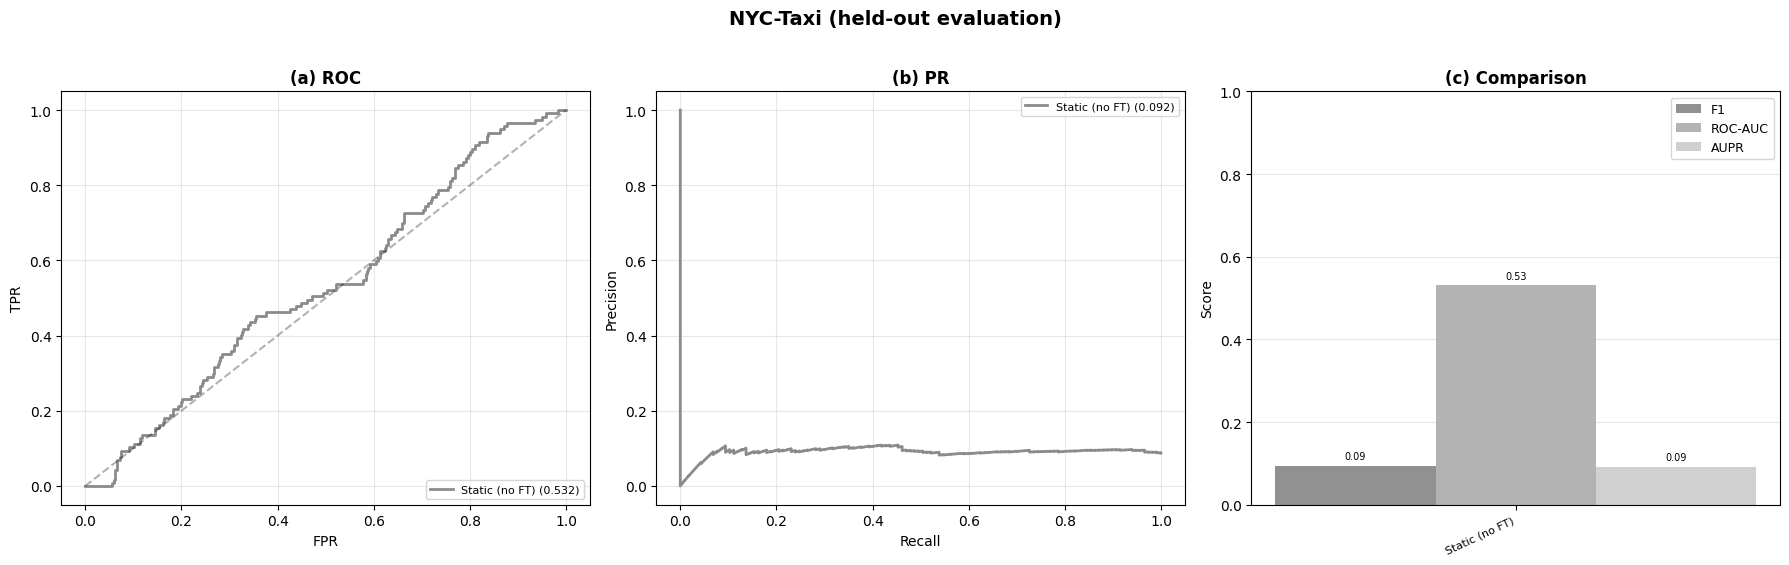

  saved: .\eval_NYC-Taxi.png

  DATASET: nab_machine


✓ Loaded 'NAB-machine_temperature_system_failure': 22695 points
  N=22695, train segment=19290, held-out=3405

  ── Stage 1 (SFT) ──
  [Naive @ nab_machine] training on 19290 pts


INFO:apache_beam.runners.worker.statecache:Creating state cache with size 104857600
INFO:root:Using local storage (GCS disabled)
INFO:root:Loading TimesFM model from path: google/timesfm-1.0-200m-pytorch...
INFO:httpx:HTTP Request: GET https://huggingface.co/api/models/google/timesfm-1.0-200m-pytorch/revision/main "HTTP/1.1 200 OK"
Fetching 3 files: 100%|██████████████████████████████████████████████████████████████████████████| 3/3 [00:00<?, ?it/s]
INFO:root:Loading checkpoint from C:\Users\robotics\.cache\huggingface\hub\models--google--timesfm-1.0-200m-pytorch\snapshots\0581e2c56cb06feb51cfd98fc2b4005b74f7187b\torch_model.ckpt
INFO:root:Sending checkpoint to device cpu
INFO:root:Model loaded successfully.
INFO:root:BatchElements statistics: element_count=0 batch_count=0 next_batch_size=1 timings=[]
INFO:root:BatchElements statistics: element_count=0 batch_count=0 next_batch_size=1 timings=[]


Current context shape: (512,)
Actual horizon values shape: (128,)


INFO:root:BatchElements statistics: element_count=1 batch_count=1 next_batch_size=1 timings=[]
INFO:root:Batching buffer now contains 100 points. Timestamps range from 128.0 to 227.0.


...

Current context shape: (512,)
Actual horizon values shape: (128,)


INFO:root:BatchElements statistics: element_count=171 batch_count=171 next_batch_size=1 timings=[]


Current context shape: (512,)
Actual horizon values shape: (128,)


INFO:root:BatchElements statistics: element_count=172 batch_count=172 next_batch_size=1 timings=[]
INFO:root:BatchElements statistics: element_count=172 batch_count=172 next_batch_size=1 timings=[]
INFO:root:BatchElements statistics: element_count=172 batch_count=172 next_batch_size=1 timings=[]
INFO:root:BatchElements statistics: element_count=172 batch_count=172 next_batch_size=1 timings=[]
INFO:root:BatchElements statistics: element_count=172 batch_count=172 next_batch_size=1 timings=[]
INFO:root:BatchElements statistics: element_count=172 batch_count=172 next_batch_size=1 timings=[]


  [eval] 172 aligned windows

  Results for NAB-machine_temperature_system_failure:
     Condition  Precision  Recall  F1  ROC-AUC     AUPR
Static (no FT)        0.0     0.0 0.0 0.708454 0.005854


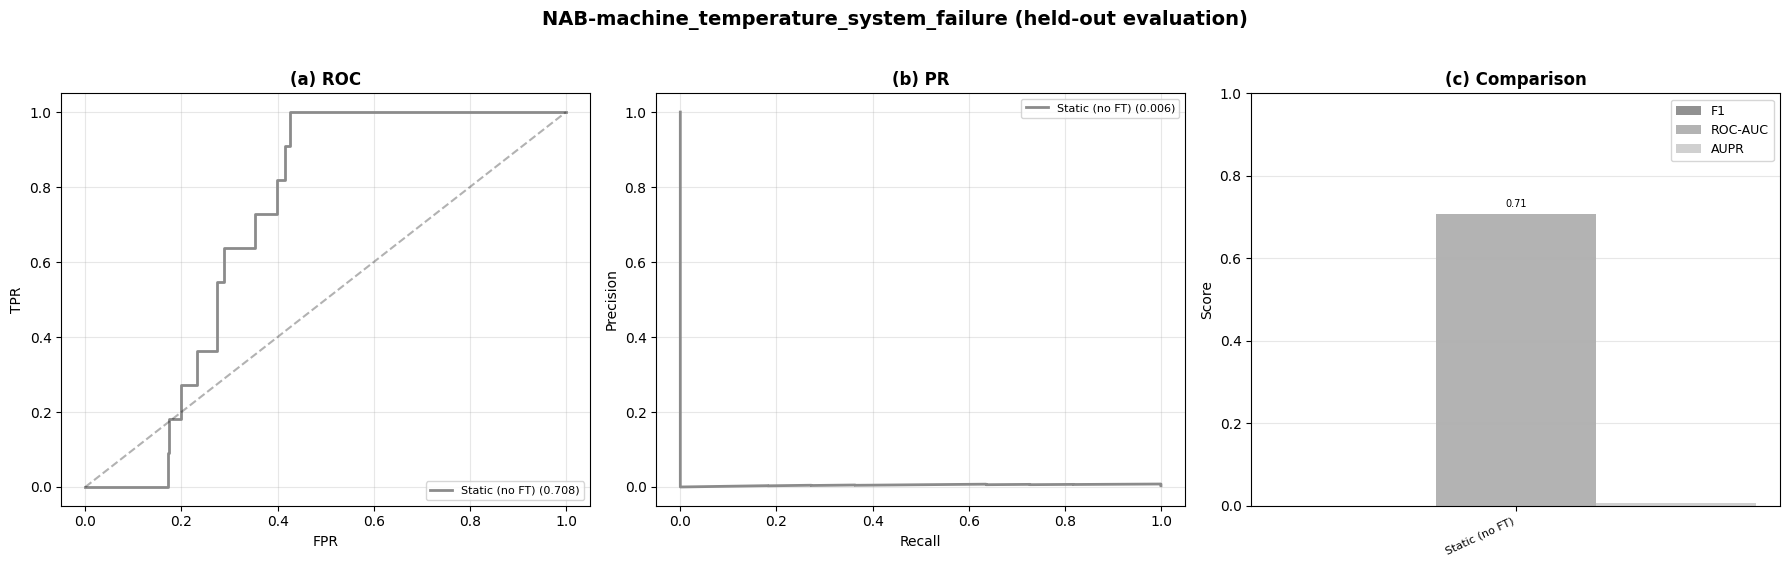

  saved: .\eval_NAB-machine_temperature_system_failure.png

  DATASET: smd_1_1
✓ Loaded 'SMD-machine-1-1': 56958 points
  N=56958, train segment=48414, held-out=8544

  ── Stage 1 (SFT) ──
  [Naive @ smd_1_1] training on 48414 pts


INFO:apache_beam.runners.worker.statecache:Creating state cache with size 104857600
INFO:root:Using local storage (GCS disabled)
INFO:root:Loading TimesFM model from path: google/timesfm-1.0-200m-pytorch...
INFO:httpx:HTTP Request: GET https://huggingface.co/api/models/google/timesfm-1.0-200m-pytorch/revision/main "HTTP/1.1 200 OK"
Fetching 3 files: 100%|████████████████████████████████████████████████████████████████| 3/3 [00:00<00:00, 2872.16it/s]
INFO:root:Loading checkpoint from C:\Users\robotics\.cache\huggingface\hub\models--google--timesfm-1.0-200m-pytorch\snapshots\0581e2c56cb06feb51cfd98fc2b4005b74f7187b\torch_model.ckpt
INFO:root:Sending checkpoint to device cpu
INFO:root:Model loaded successfully.
INFO:root:BatchElements statistics: element_count=0 batch_count=0 next_batch_size=1 timings=[]
INFO:root:BatchElements statistics: element_count=0 batch_count=0 next_batch_size=1 timings=[]


Current context shape: (512,)
Actual horizon values shape: (128,)


INFO:root:BatchElements statistics: element_count=1 batch_count=1 next_batch_size=1 timings=[]
INFO:root:Batching buffer now contains 100 points. Timestamps range from 128.0 to 227.0.


Current context shape: (512,)
Actual horizon values shape: (128,)


...

Current context shape: (512,)
Actual horizon values shape: (128,)


INFO:root:BatchElements statistics: element_count=438 batch_count=438 next_batch_size=1 timings=[]


Current context shape: (512,)
Actual horizon values shape: (128,)


INFO:root:BatchElements statistics: element_count=439 batch_count=439 next_batch_size=1 timings=[]
INFO:root:BatchElements statistics: element_count=439 batch_count=439 next_batch_size=1 timings=[]
INFO:root:BatchElements statistics: element_count=439 batch_count=439 next_batch_size=1 timings=[]
INFO:root:BatchElements statistics: element_count=439 batch_count=439 next_batch_size=1 timings=[]
INFO:root:BatchElements statistics: element_count=439 batch_count=439 next_batch_size=1 timings=[]
INFO:root:BatchElements statistics: element_count=439 batch_count=439 next_batch_size=1 timings=[]


  [eval] 439 aligned windows

  Results for SMD-machine-1-1:
     Condition  Precision   Recall       F1  ROC-AUC     AUPR
Static (no FT)   0.135514 0.203866 0.162807 0.643141 0.100991


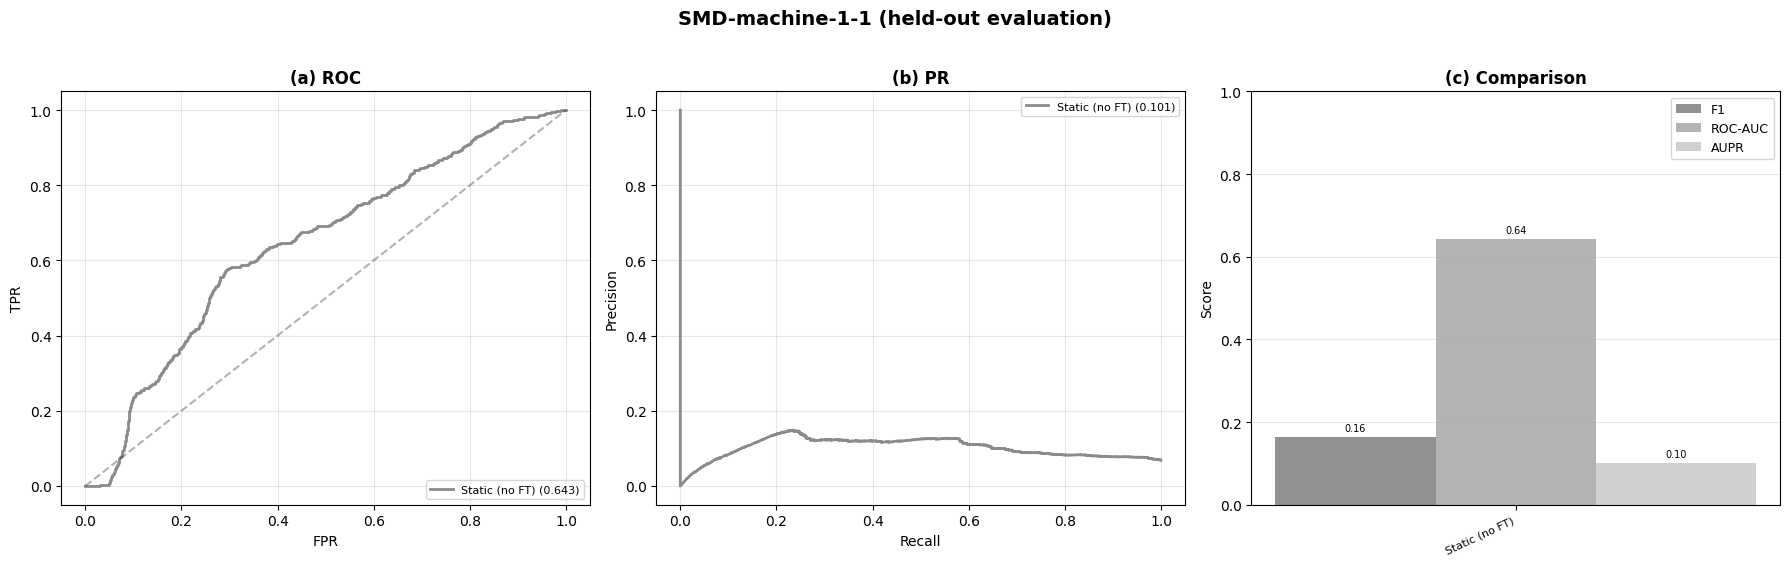

  saved: .\eval_SMD-machine-1-1.png

  ALL DATASETS DONE  (3 result rows)

Saved: results_all.csv

                               Dataset      Condition  n_held_out_pts  n_held_out_anomalies  Precision   Recall       F1  ROC-AUC     AUPR
                              NYC-Taxi Static (no FT)            1340                   117   0.082278 0.111111 0.094545 0.532221 0.092245
NAB-machine_temperature_system_failure Static (no FT)            3238                    11   0.000000 0.000000 0.000000 0.708454 0.005854
                       SMD-machine-1-1 Static (no FT)            8290                   569   0.135514 0.203866 0.162807 0.643141 0.100991


In [18]:
# Per-dataset, per-condition results
ALL_RESULTS = []
ALL_CURVES_BY_DATASET = {}

for ds_key in BENCHMARK_DATASETS:
    print(f"\n{'='*78}\n  DATASET: {ds_key}\n{'='*78}")

    # 1. Load
    input_data, dataset_name = load_dataset(ds_key)
    n = len(input_data)
    train_idx = int(n * (1 - HELD_OUT_FRACTION))
    input_data_train = input_data[:train_idx]
    print(f"  N={n}, train segment={train_idx}, held-out={n-train_idx}")

    # 2. Train Stage 1 (SFT) for all conditions
    print(f"\n  ── Stage 1 (SFT) ──")
    naive_ckpt  = train_naive_condition(input_data_train, ds_key)
    gemini_ckpt = train_gemini_condition(input_data_train, ds_key, api_key_gemini)
    claude_ckpt = train_claude_condition(input_data_train, ds_key, api_key_claude)

    print(f"\n  SFT checkpoints:")
    print(f"    Naive:  {naive_ckpt}")
    print(f"    Gemini: {gemini_ckpt}")
    print(f"    Claude: {claude_ckpt}")

    # 3. Train Stage 2 (RL) starting from the Gemini SFT checkpoint
    print(f"\n  ── Stage 2 (RL) ──")
    rl_ckpt = None
    if gemini_ckpt:
        rl_ckpt = train_rl_stage2_condition(
            sft_ckpt_path=gemini_ckpt,
            input_data_train=input_data_train,
            dataset_tag=ds_key,
            llm_kind="gemini",
            api_key=api_key_gemini,
        )
    elif claude_ckpt:
        # Fallback: if no Gemini, run RL on top of Claude SFT instead
        rl_ckpt = train_rl_stage2_condition(
            sft_ckpt_path=claude_ckpt,
            input_data_train=input_data_train,
            dataset_tag=ds_key,
            llm_kind="claude",
            api_key=api_key_claude,
        )
    elif naive_ckpt:
        # Fallback: RL on top of Naive SFT, no LLM feedback (gamma=0)
        rl_ckpt = train_rl_stage2_condition(
            sft_ckpt_path=naive_ckpt,
            input_data_train=input_data_train,
            dataset_tag=ds_key,
            llm_kind="none",
            api_key=None,
        )

    print(f"  RL checkpoint: {rl_ckpt}")

    # 4. Evaluate all 5 conditions
    print(f"\n  ── Evaluation ──")
    results, curves = evaluate_dataset(
        ds_key, dataset_name, input_data,
        ckpts={
            "naive":   naive_ckpt,
            "gemini":  gemini_ckpt,
            "claude":  claude_ckpt,
            "rl":      rl_ckpt,
        },
    )
    ALL_RESULTS.extend(results)
    ALL_CURVES_BY_DATASET[dataset_name] = curves

print(f"\n{'='*78}\n  ALL DATASETS DONE  ({len(ALL_RESULTS)} result rows)\n{'='*78}")
import pandas as pd
df_all = pd.DataFrame(ALL_RESULTS)
df_all.to_csv("results_all.csv", index=False)
print("\nSaved: results_all.csv\n")
print(df_all.to_string(index=False))


## Cross-dataset comparison figures

Six figures comparing the 4 conditions across all 3 datasets.

1. **Bar — F1** by condition × dataset
2. **Bar — AUPR** by condition × dataset
3. **Bar — ROC-AUC** by condition × dataset
4. **Heatmap** of F1 (conditions × datasets)
5. **Slope chart** showing per-dataset F1 progression Static → Naive → Gemini/Claude
6. **Aggregate ROC + PR**: one panel per dataset, all 4 conditions overlaid

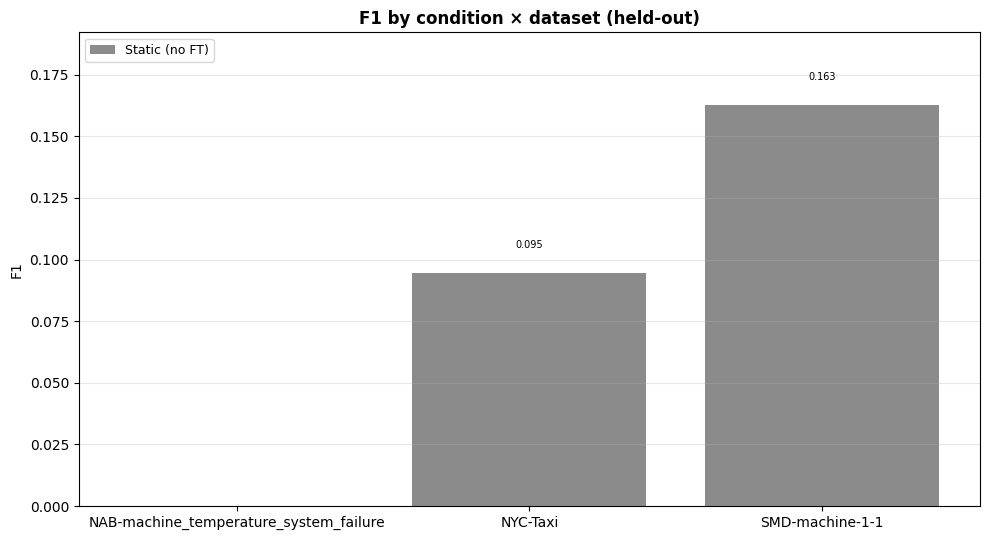

saved: fig1_F1_bars.png


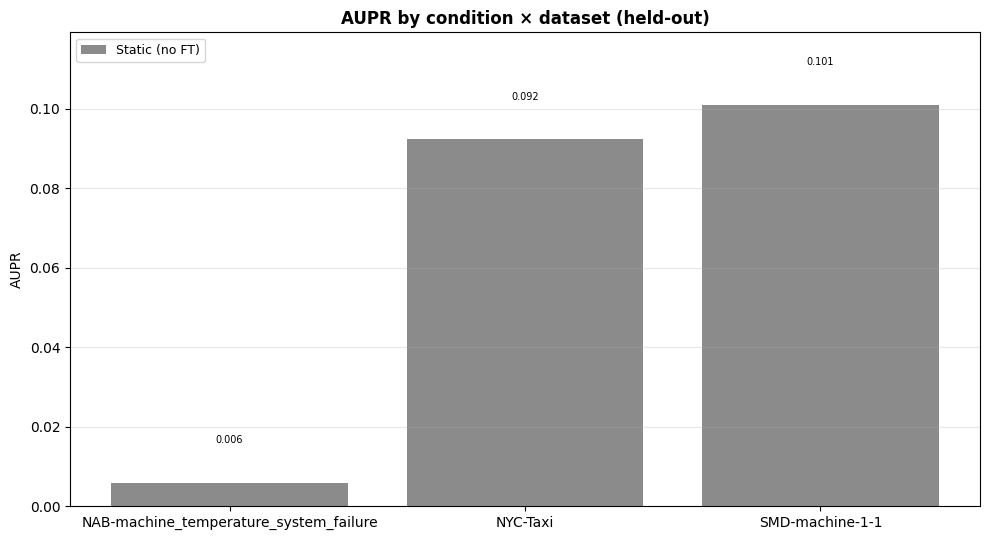

saved: fig2_AUPR_bars.png


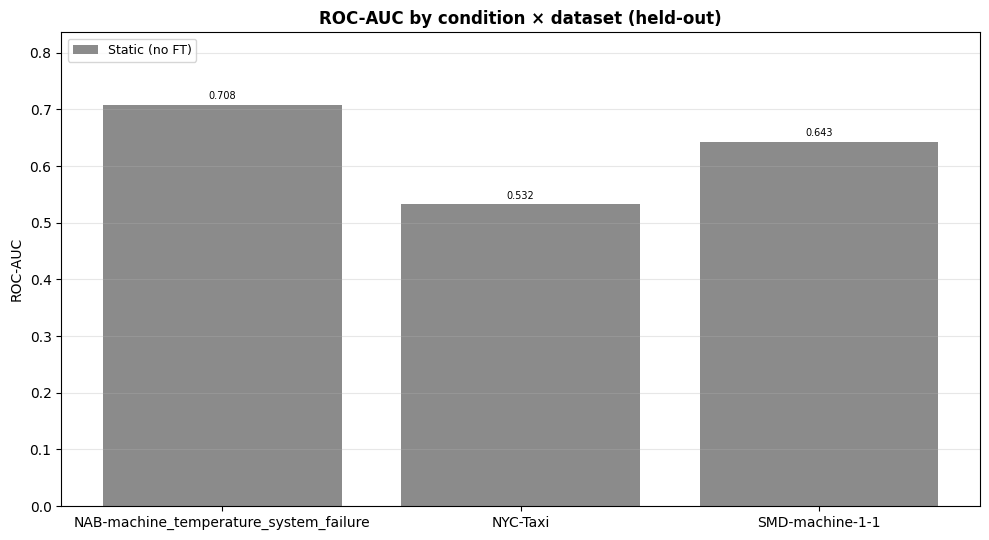

saved: fig3_AUC_bars.png


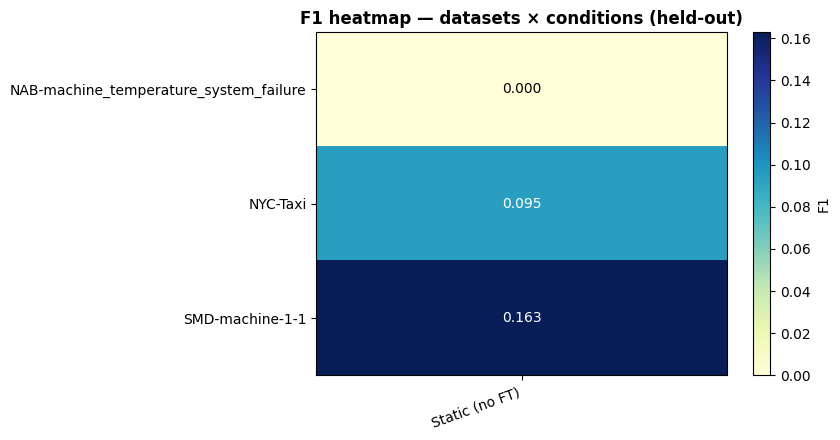

saved: fig4_F1_heatmap.png


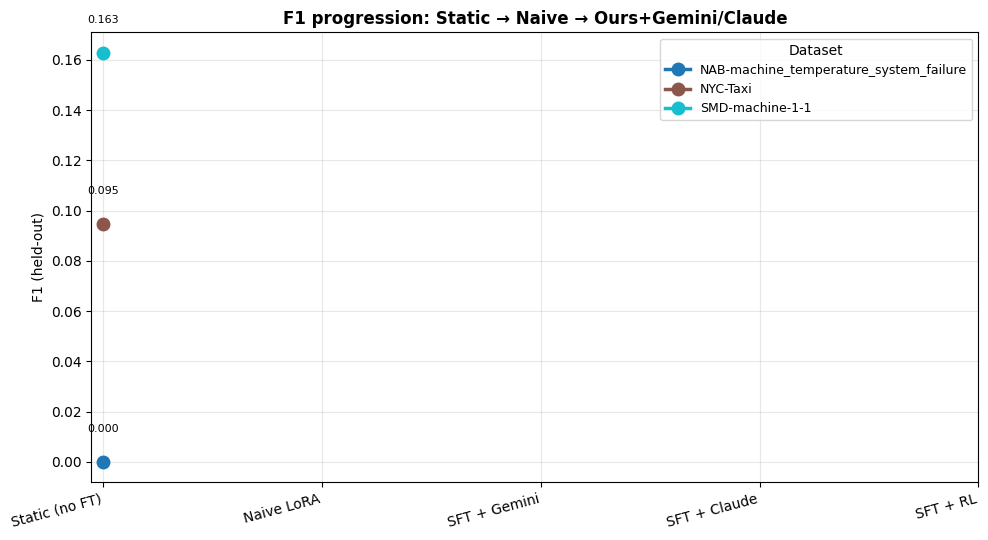

saved: fig5_F1_slope.png


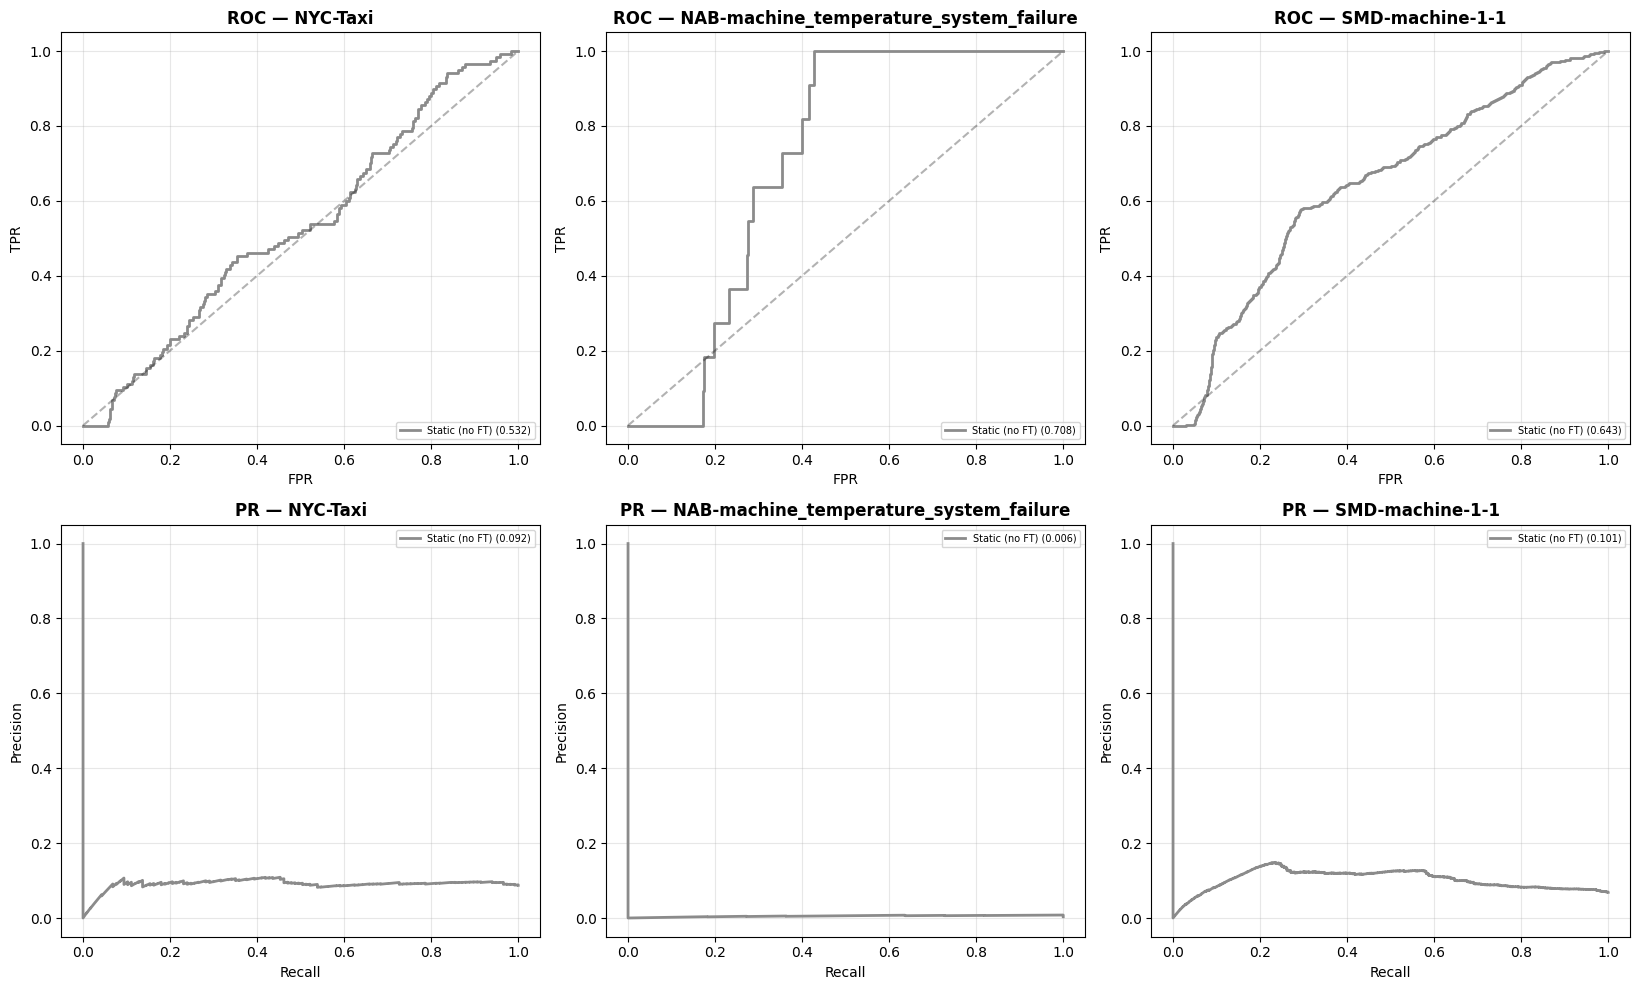

saved: fig6_ROC_PR_grid.png

  FINAL SUMMARY — all conditions × all datasets
                               Dataset      Condition  n_held_out_pts  n_held_out_anomalies Precision Recall     F1 ROC-AUC   AUPR
                              NYC-Taxi Static (no FT)            1340                   117    0.0823 0.1111 0.0945  0.5322 0.0922
NAB-machine_temperature_system_failure Static (no FT)            3238                    11    0.0000 0.0000 0.0000  0.7085 0.0059
                       SMD-machine-1-1 Static (no FT)            8290                   569    0.1355 0.2039 0.1628  0.6431 0.1010

All results saved to results_all.csv
All figures saved to fig1..fig6 + per-dataset eval_*.png
(no RL training logs found — skipping FIG 7)


In [19]:

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import roc_curve, precision_recall_curve, roc_auc_score, average_precision_score

df = pd.DataFrame(ALL_RESULTS)
if len(df) == 0:
    raise SystemExit("No results to plot.")

CONDS = ["Static (no FT)", "Naive LoRA", "SFT + Gemini", "SFT + Claude", "SFT + RL"]
DSETS = sorted(df["Dataset"].unique())
COLORS = {"Static (no FT)": "#8B8B8B", "Naive LoRA": "#E07A5F",
          "SFT + Gemini": "#3D85C6", "SFT + Claude": "#81B29A",
          "SFT + RL": "#9B5DE5"}

# Pivot helpers
def pivot_metric(metric):
    p = df.pivot_table(index="Dataset", columns="Condition", values=metric, aggfunc="mean")
    return p.reindex(index=DSETS, columns=[c for c in CONDS if c in p.columns])


# ── FIG 1, 2, 3: Grouped bar charts for F1, AUPR, ROC-AUC ────────────────────
def grouped_bar(metric, title, fname):
    pv = pivot_metric(metric)
    if pv.empty: return
    fig, ax = plt.subplots(figsize=(10, 5.5))
    n_ds = len(pv.index); n_co = len(pv.columns)
    width = 0.8 / max(n_co, 1)
    x = np.arange(n_ds)
    for j, cond in enumerate(pv.columns):
        vals = pv[cond].fillna(0).values
        bars = ax.bar(x + (j - (n_co-1)/2) * width, vals, width,
                      label=cond, color=COLORS.get(cond, "#333"))
        for b, v in zip(bars, vals):
            if v > 0.005:
                ax.text(b.get_x() + b.get_width()/2, v + 0.01,
                        f"{v:.3f}", ha="center", fontsize=7)
    ax.set_xticks(x); ax.set_xticklabels(pv.index, fontsize=10)
    ax.set_ylabel(metric); ax.set_title(title, fontweight="bold")
    ax.legend(fontsize=9, loc="upper left"); ax.grid(True, alpha=0.3, axis="y")
    ax.set_ylim([0, max(0.05, pv.values.max() * 1.18) if not np.isnan(pv.values).all() else 1])
    plt.tight_layout()
    plt.savefig(fname, dpi=200, bbox_inches="tight"); plt.show()
    print(f"saved: {fname}")

grouped_bar("F1",      "F1 by condition × dataset (held-out)",      "fig1_F1_bars.png")
grouped_bar("AUPR",    "AUPR by condition × dataset (held-out)",    "fig2_AUPR_bars.png")
grouped_bar("ROC-AUC", "ROC-AUC by condition × dataset (held-out)", "fig3_AUC_bars.png")


# ── FIG 4: Heatmap of F1 ────────────────────────────────────────────────────
pv_f1 = pivot_metric("F1")
fig, ax = plt.subplots(figsize=(8.5, 4.5))
im = ax.imshow(pv_f1.values, cmap="YlGnBu", aspect="auto", vmin=0,
               vmax=max(0.05, np.nan_to_num(pv_f1.values).max()))
for i in range(pv_f1.shape[0]):
    for j in range(pv_f1.shape[1]):
        v = pv_f1.iloc[i, j]
        if not np.isnan(v):
            ax.text(j, i, f"{v:.3f}", ha="center", va="center",
                    color="white" if v > pv_f1.values.max()/2 else "black", fontsize=10)
ax.set_xticks(range(len(pv_f1.columns))); ax.set_xticklabels(pv_f1.columns, rotation=20, ha="right")
ax.set_yticks(range(len(pv_f1.index)));   ax.set_yticklabels(pv_f1.index)
fig.colorbar(im, ax=ax, label="F1")
ax.set_title("F1 heatmap — datasets × conditions (held-out)", fontweight="bold")
plt.tight_layout()
plt.savefig("fig4_F1_heatmap.png", dpi=200, bbox_inches="tight"); plt.show()
print("saved: fig4_F1_heatmap.png")


# ── FIG 5: Slope chart (each dataset is a line, conditions on x) ────────────
fig, ax = plt.subplots(figsize=(10, 5.5))
ds_palette = plt.cm.tab10(np.linspace(0, 1, max(len(DSETS), 1)))
for i, ds in enumerate(DSETS):
    sub = df[df["Dataset"] == ds].set_index("Condition").reindex(CONDS)
    ys = sub["F1"].values
    xs = np.arange(len(CONDS))
    ax.plot(xs, ys, "o-", color=ds_palette[i], linewidth=2.5, markersize=9, label=ds)
    for x_, y_ in zip(xs, ys):
        if not np.isnan(y_):
            ax.text(x_, y_+0.012, f"{y_:.3f}", ha="center", fontsize=8)
ax.set_xticks(range(len(CONDS))); ax.set_xticklabels(CONDS, rotation=15, ha="right")
ax.set_ylabel("F1 (held-out)"); ax.set_title("F1 progression: Static → Naive → Ours+Gemini/Claude", fontweight="bold")
ax.legend(fontsize=9, title="Dataset"); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("fig5_F1_slope.png", dpi=200, bbox_inches="tight"); plt.show()
print("saved: fig5_F1_slope.png")


# ── FIG 6: Aggregate ROC + PR (one row of subplots per metric) ──────────────
n_ds = len(ALL_CURVES_BY_DATASET)
fig, axes = plt.subplots(2, n_ds, figsize=(5.5*n_ds, 10), squeeze=False)
for col, (ds_name, curves) in enumerate(ALL_CURVES_BY_DATASET.items()):
    # ROC
    ax = axes[0, col]
    for lb, (sc, tr) in curves.items():
        if len(set(tr)) < 2: continue
        fpr, tpr, _ = roc_curve(tr, sc); auc = roc_auc_score(tr, sc)
        ax.plot(fpr, tpr, label=f"{lb} ({auc:.3f})", color=COLORS.get(lb, "#333"), linewidth=2)
    ax.plot([0,1],[0,1], "k--", alpha=0.3)
    ax.set_xlabel("FPR"); ax.set_ylabel("TPR")
    ax.set_title(f"ROC — {ds_name}", fontweight="bold")
    ax.legend(fontsize=7, loc="lower right"); ax.grid(True, alpha=0.3)
    # PR
    ax = axes[1, col]
    for lb, (sc, tr) in curves.items():
        if len(set(tr)) < 2: continue
        pr, rc, _ = precision_recall_curve(tr, sc); ap = average_precision_score(tr, sc)
        ax.plot(rc, pr, label=f"{lb} ({ap:.3f})", color=COLORS.get(lb, "#333"), linewidth=2)
    ax.set_xlabel("Recall"); ax.set_ylabel("Precision")
    ax.set_title(f"PR — {ds_name}", fontweight="bold")
    ax.legend(fontsize=7); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("fig6_ROC_PR_grid.png", dpi=200, bbox_inches="tight"); plt.show()
print("saved: fig6_ROC_PR_grid.png")


# ── Final summary table ─────────────────────────────────────────────────────
print(f"\n{'='*78}\n  FINAL SUMMARY — all conditions × all datasets\n{'='*78}")
display_cols = ["Dataset", "Condition", "n_held_out_pts", "n_held_out_anomalies",
                "Precision", "Recall", "F1", "ROC-AUC", "AUPR"]
df_display = df[display_cols].copy()
for c in ["Precision","Recall","F1","ROC-AUC","AUPR"]:
    df_display[c] = df_display[c].apply(lambda x: f"{x:.4f}" if pd.notnull(x) else "N/A")
print(df_display.to_string(index=False))
print(f"\nAll results saved to results_all.csv")
print(f"All figures saved to fig1..fig6 + per-dataset eval_*.png")



# ── FIG 7: RL training curves (one panel per dataset) ──────────────────────
import glob, pandas as pd, matplotlib.pyplot as plt
rl_logs = sorted(glob.glob("rl_training_log_*.csv"))
if rl_logs:
    fig, axes = plt.subplots(len(rl_logs), 3, figsize=(15, 4*len(rl_logs)),
                             squeeze=False)
    for row, log_path in enumerate(rl_logs):
        ds_tag = os.path.basename(log_path).replace("rl_training_log_", "").replace(".csv", "")
        df_rl = pd.read_csv(log_path)

        # (a) Reward over steps
        ax = axes[row, 0]
        ax.plot(df_rl["step"], df_rl["reward"], "o-", color="#9B5DE5", markersize=3, label="reward")
        ax.plot(df_rl["step"], df_rl["baseline"], "--", color="gray", alpha=0.7, label="baseline")
        ax.axhline(0, color="black", alpha=0.3, linewidth=0.5)
        ax.set_xlabel("step"); ax.set_ylabel("reward")
        ax.set_title(f"{ds_tag} — reward", fontweight="bold")
        ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

        # (b) Reward components
        ax = axes[row, 1]
        ax.plot(df_rl["step"], df_rl["r_calib"], "-",  label="calibration",  linewidth=1.5)
        ax.plot(df_rl["step"], df_rl["r_sharp"], "-",  label="-sharpness",   linewidth=1.5)
        ax.plot(df_rl["step"], df_rl["r_llm"],   "-",  label="LLM score",    linewidth=1.5)
        ax.set_xlabel("step"); ax.set_ylabel("component")
        ax.set_title(f"{ds_tag} — reward components", fontweight="bold")
        ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

        # (c) KL divergence
        ax = axes[row, 2]
        ax.plot(df_rl["step"], df_rl["kl"], "-", color="#E07A5F", linewidth=1.5)
        ax.set_xlabel("step"); ax.set_ylabel("KL(π || π_SFT)")
        ax.set_title(f"{ds_tag} — KL drift", fontweight="bold")
        ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig("fig7_RL_training.png", dpi=200, bbox_inches="tight")
    plt.show()
    print("saved: fig7_RL_training.png")
else:
    print("(no RL training logs found — skipping FIG 7)")
